### **Análisis de la base de datos**

In [35]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score,f1_score, precision_score ,recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
from scipy.stats import chi2_contingency
warnings.filterwarnings('ignore')

In [36]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [37]:
df.dtypes

Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

In [38]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


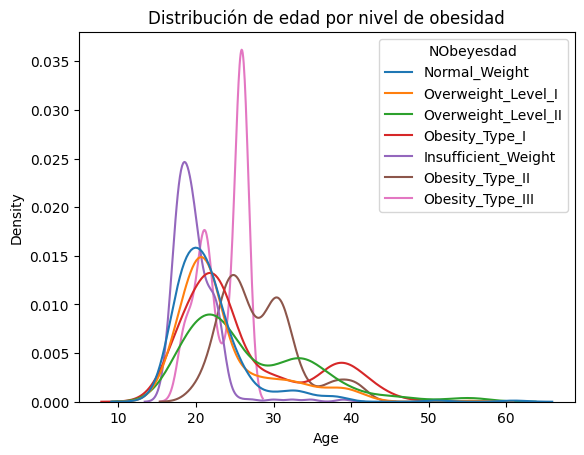

In [39]:
sns.kdeplot(data=df, x='Age', hue='NObeyesdad')
plt.title("Distribución de edad por nivel de obesidad")
plt.show()

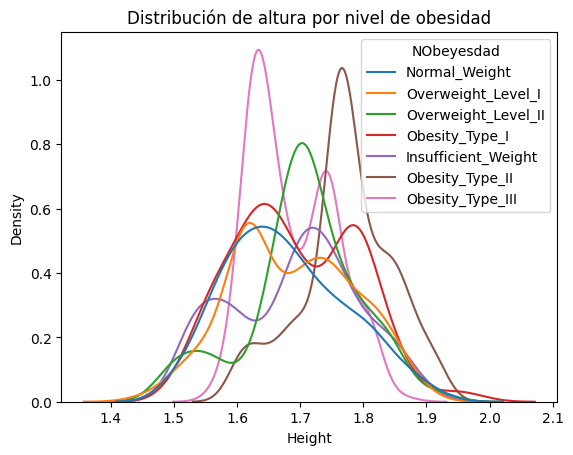

In [40]:
sns.kdeplot(data=df, x='Height', hue='NObeyesdad')
plt.title("Distribución de altura por nivel de obesidad")
plt.show()

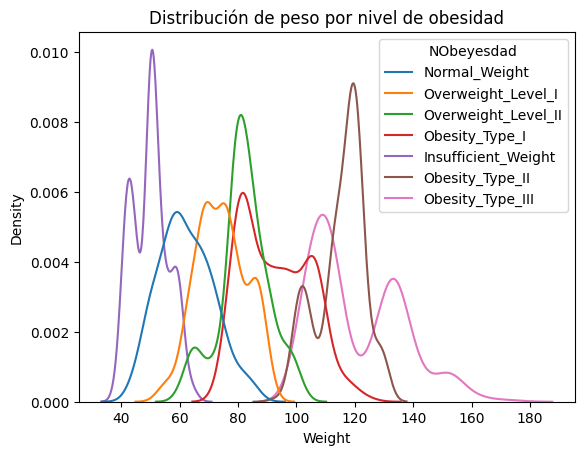

In [41]:
sns.kdeplot(data=df, x='Weight', hue='NObeyesdad')
plt.title("Distribución de peso por nivel de obesidad")
plt.show()

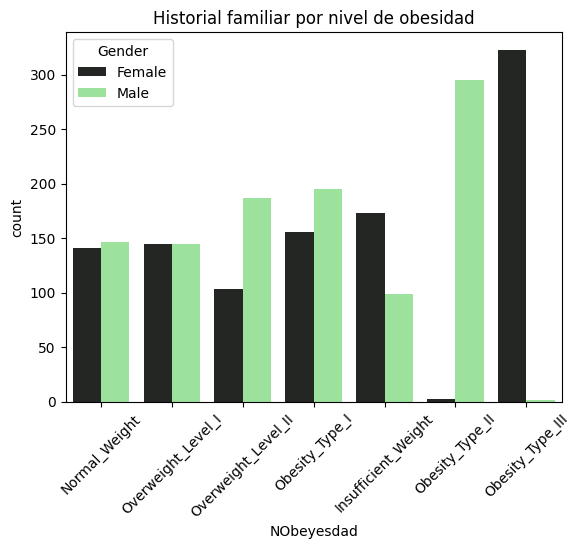

In [42]:
sns.countplot(x='NObeyesdad', hue='Gender', data=df, color='lightgreen')
plt.xticks(rotation=45)
plt.title("Historial familiar por nivel de obesidad")
plt.show()

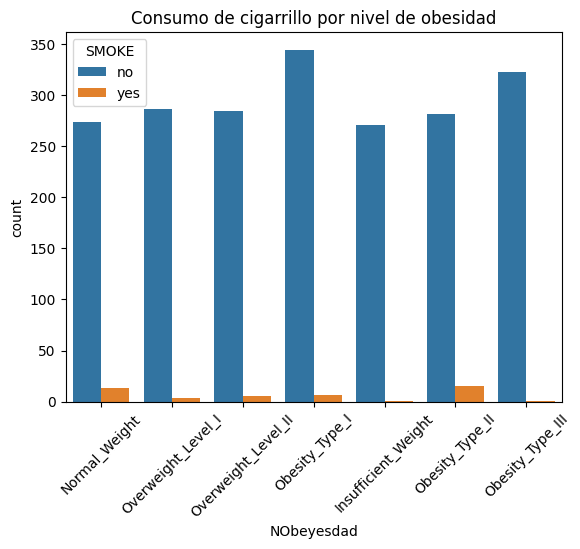

In [43]:
sns.countplot(x='NObeyesdad', hue='SMOKE', data=df)
plt.xticks(rotation=45)
plt.title("Consumo de cigarrillo por nivel de obesidad")
plt.show()

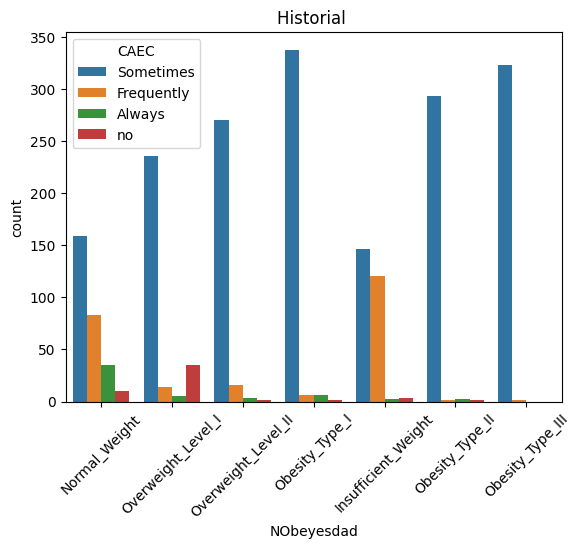

In [44]:
sns.countplot(x='NObeyesdad', hue='CAEC', data=df)
plt.xticks(rotation=45)
plt.title("Historial ")
plt.show()

**Varible objetivo**

In [45]:
df.groupby('NObeyesdad').NObeyesdad.count().sort_values(ascending=False)

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: NObeyesdad, dtype: int64

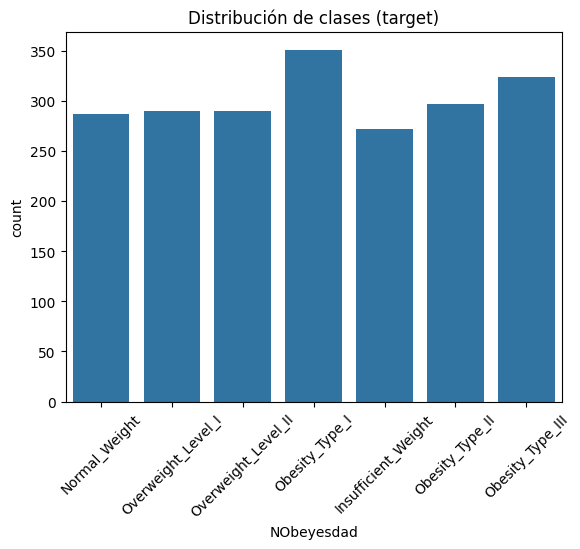

NObeyesdad
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88
Name: proportion, dtype: float64


In [46]:
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.title("Distribución de clases (target)")
plt.show()
print(df['NObeyesdad'].value_counts(normalize=True).mul(100).round(2))

### **Selección de características y extracción de características**

**Filtros (Correlación, Anova, Chi2, colinealidad)**

In [47]:
num=df.select_dtypes(include = ['float64']).columns.tolist()
cat = df.select_dtypes(include = ["object"]).columns.tolist()

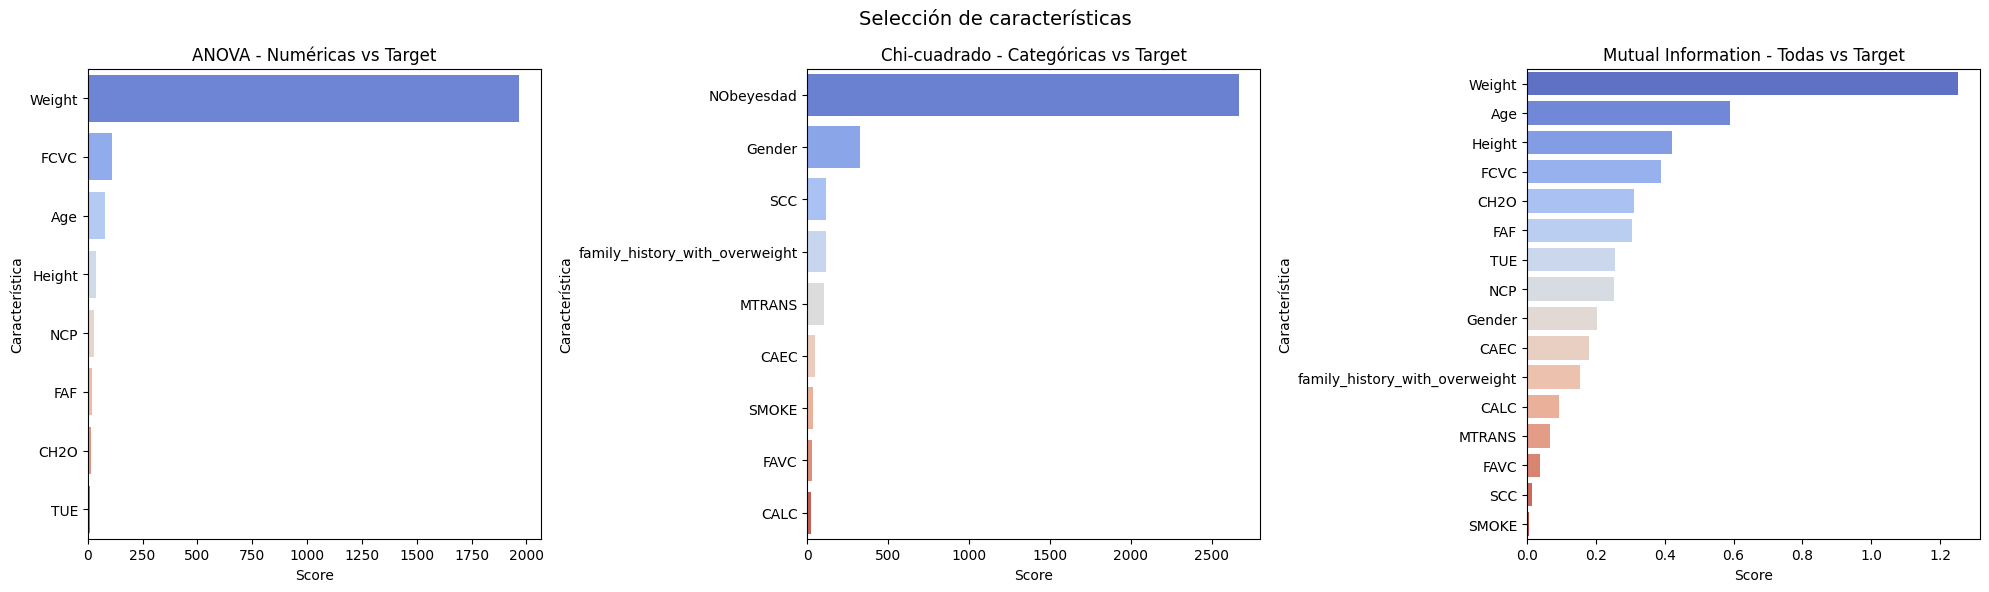

In [48]:
#Anova
anova_selector = SelectKBest(score_func=f_classif, k="all")
anova_selector.fit(df[num], df['NObeyesdad'])

scores_anova = pd.DataFrame({
    "Característica": num,
    "Score": anova_selector.scores_
}).sort_values(by="Score", ascending=False)


#Chi2
X_cat = OrdinalEncoder().fit_transform(df[cat])

chi2_scores, _ = chi2(X_cat, df['NObeyesdad'])

scores_chi2 = pd.DataFrame({
    "Característica": cat,
    "Score": chi2_scores
}).sort_values(by="Score", ascending=False)


#Mutual Information
df_mi = df.copy()

df_mi[cat] = OrdinalEncoder().fit_transform(df_mi[cat])
df_mi['NObeyesdad'] = LabelEncoder().fit_transform(df_mi['NObeyesdad'])

X = df_mi.drop(columns=['NObeyesdad'])
y = df_mi['NObeyesdad']

mi_scores = mutual_info_classif(X, y, random_state=0)

scores_mi = pd.DataFrame({
    "Característica": X.columns,
    "Score": mi_scores
}).sort_values(by="Score", ascending=False)

#Gráfico
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x="Score", y="Característica", data=scores_anova,
            hue="Característica", dodge=False, palette="coolwarm",
            legend=False, ax=axes[0])
axes[0].set_title("ANOVA - Numéricas vs Target")

sns.barplot(x="Score", y="Característica", data=scores_chi2,
            hue="Característica", dodge=False, palette="coolwarm",
            legend=False, ax=axes[1])
axes[1].set_title("Chi-cuadrado - Categóricas vs Target")

sns.barplot(x="Score", y="Característica", data=scores_mi,
            hue="Característica", dodge=False, palette="coolwarm",
            legend=False, ax=axes[2])
axes[2].set_title("Mutual Information - Todas vs Target")

plt.suptitle("Selección de características", fontsize=14)
plt.tight_layout()
plt.show()



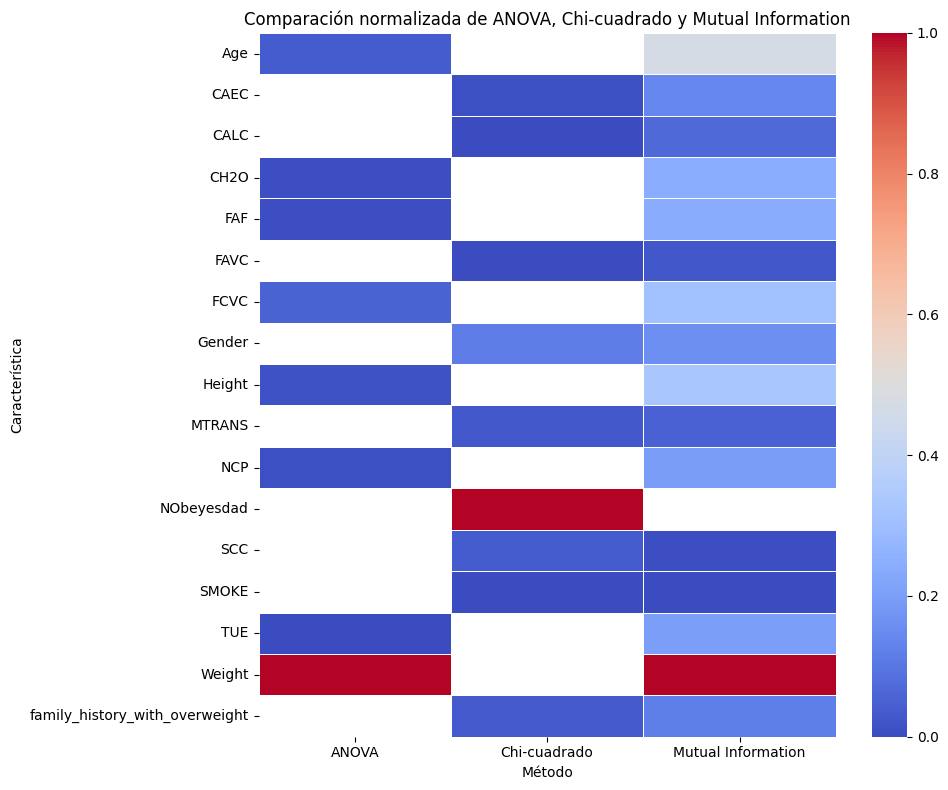

In [49]:
scaler = MinMaxScaler()

scores_anova['Score_norm'] = scaler.fit_transform(scores_anova[['Score']])
scores_chi2['Score_norm'] = scaler.fit_transform(scores_chi2[['Score']])
scores_mi['Score_norm'] = scaler.fit_transform(scores_mi[['Score']])

scores_anova['Método'] = 'ANOVA'
scores_chi2['Método'] = 'Chi-cuadrado'
scores_mi['Método'] = 'Mutual Information'

todos = pd.concat([
    scores_anova[['Característica', 'Score_norm', 'Método']],
    scores_chi2[['Característica', 'Score_norm', 'Método']],
    scores_mi[['Característica', 'Score_norm', 'Método']]
])

pivot = todos.pivot(index='Característica', columns='Método', values='Score_norm')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, cmap="coolwarm",
            linewidths=0.5, vmin=0, vmax=1)
plt.title("Comparación normalizada de ANOVA, Chi-cuadrado y Mutual Information")
plt.tight_layout()
plt.show()

**Colinealidad**

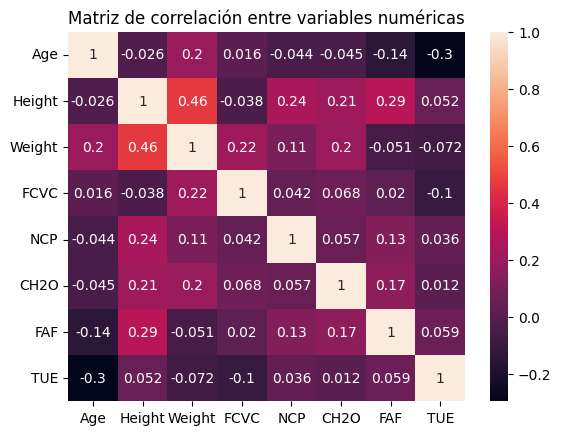

In [50]:
corr = df[num].corr()
num=df.select_dtypes(include = ['float64']).columns.tolist()
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

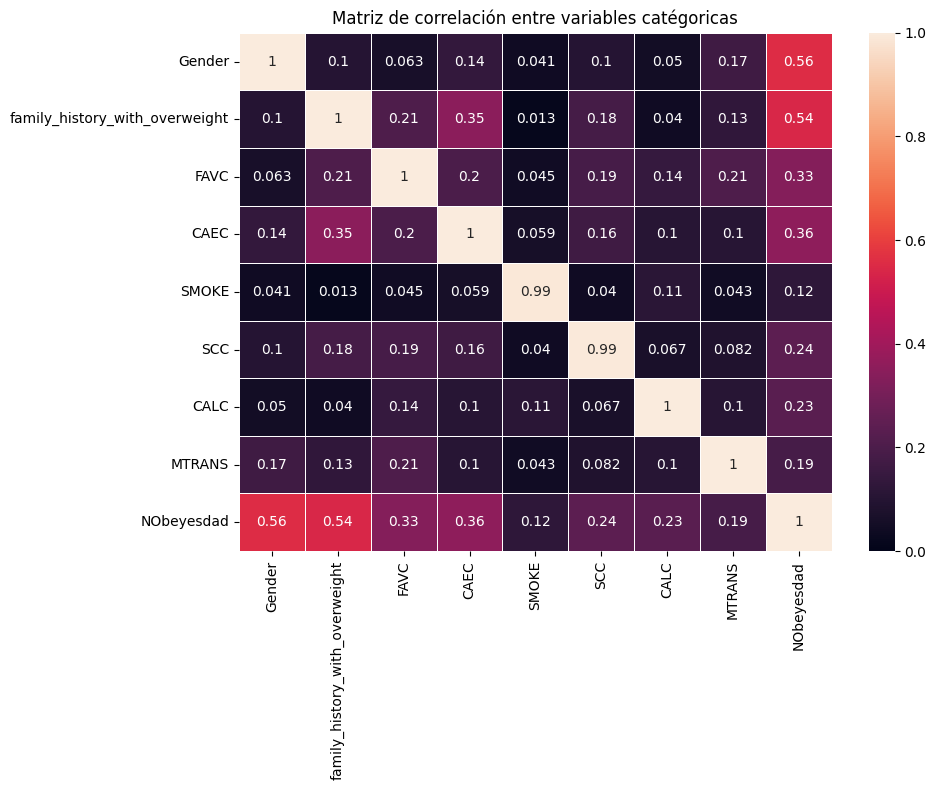

In [51]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(tabla)
    n = len(x)
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

matriz = pd.DataFrame(index=cat, columns=cat, dtype=float)

for col1 in cat:
    for col2 in cat:
        matriz.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True,
            linewidths=0.5, vmin=0, vmax=1)
plt.title("Matriz de correlación entre variables catégoricas")
plt.tight_layout()
plt.show()

**Primer y segundo subconjunto de datos**

In [52]:
#Subconjunto completo sin target ni altura (que es la variable junto a peso que definen el IBM)
primer_x = df.drop(columns=['NObeyesdad', 'Height'])

#Subconjunto al analizar correlación y colinealidad
segundo_x = primer_x.drop(columns=['SMOKE', 'FAVC', 'CALC'])


**Extracción de características (PCA)**

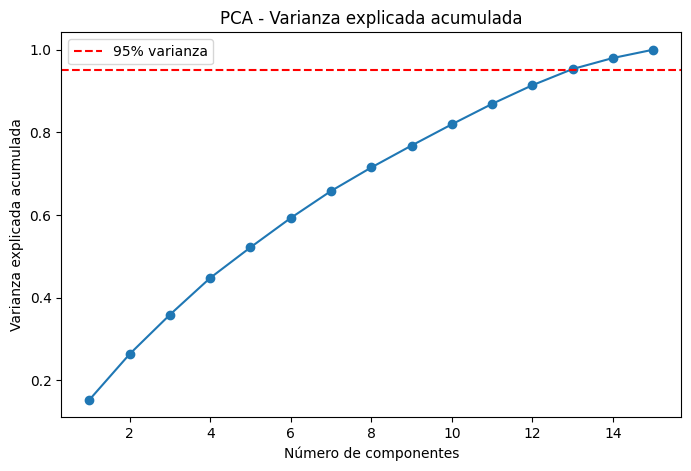

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Preparar X
df_pca = df.drop(columns=['NObeyesdad', 'Height']).copy()
cat_sin_target = [col for col in cat if col != 'NObeyesdad']
df_pca[cat_sin_target] = OrdinalEncoder().fit_transform(df_pca[cat_sin_target])

# Estandarizar
scaler = StandardScaler()
X_std = scaler.fit_transform(df_pca)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Varianza explicada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.legend()
plt.show()

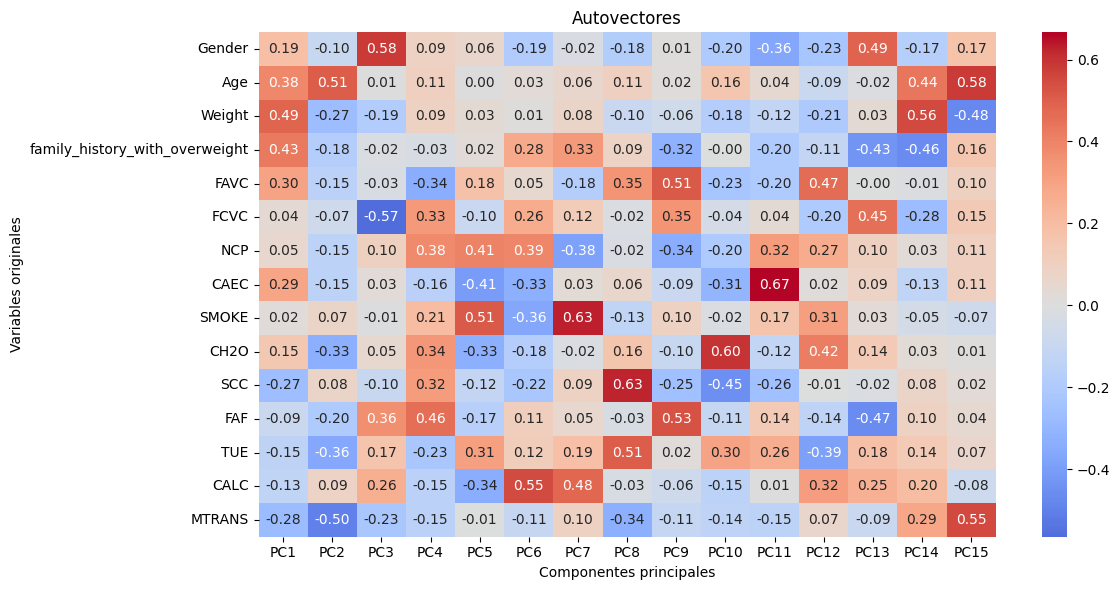

In [54]:
componentes = pd.DataFrame(pca.components_.T,
                            columns=[f'PC{i+1}' for i in range(len(df_pca.columns))],
                            index=df_pca.columns)

plt.figure(figsize=(12, 6))
sns.heatmap(componentes, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Autovectores')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

In [55]:
n_componentes = np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.90) + 1
pca_final = PCA(n_components=n_componentes)
X_pca_final = pca_final.fit_transform(X_std)

Matriz resumen de varianza explicada:

   Componente  Autovalor    PVE  PVE acumulada
0         PC1      2.292  0.153          0.153
1         PC2      1.662  0.111          0.263
2         PC3      1.430  0.095          0.359
3         PC4      1.334  0.089          0.448
4         PC5      1.111  0.074          0.522
5         PC6      1.067  0.071          0.593
6         PC7      0.979  0.065          0.658
7         PC8      0.854  0.057          0.715
8         PC9      0.797  0.053          0.768
9        PC10      0.772  0.051          0.819
10       PC11      0.742  0.049          0.869
11       PC12      0.677  0.045          0.914


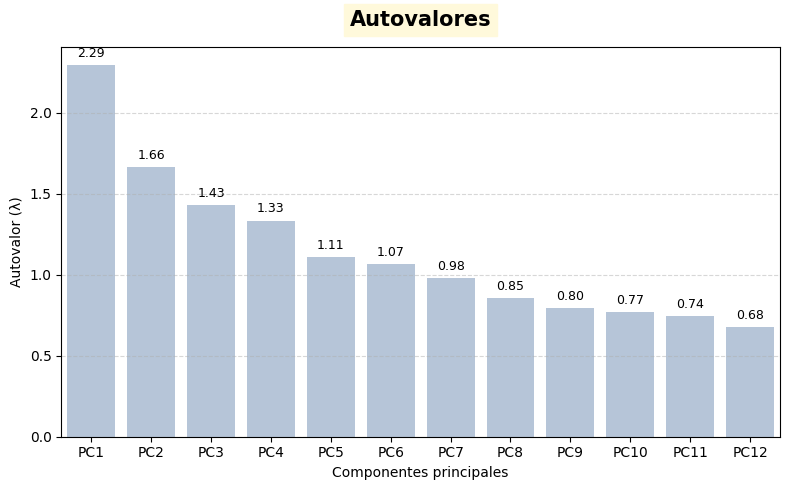

In [56]:
varianza = pca_final.explained_variance_
PVE = pca_final.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

print("Matriz resumen de varianza explicada:\n")
print(df_varianza.round(3))

# --------------------------
# Gráfico 1: Autovalores
# --------------------------
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
for i, v in enumerate(df_varianza['Autovalor']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.title("Autovalores", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Autovalor (λ)")
plt.xlabel("Componentes principales")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

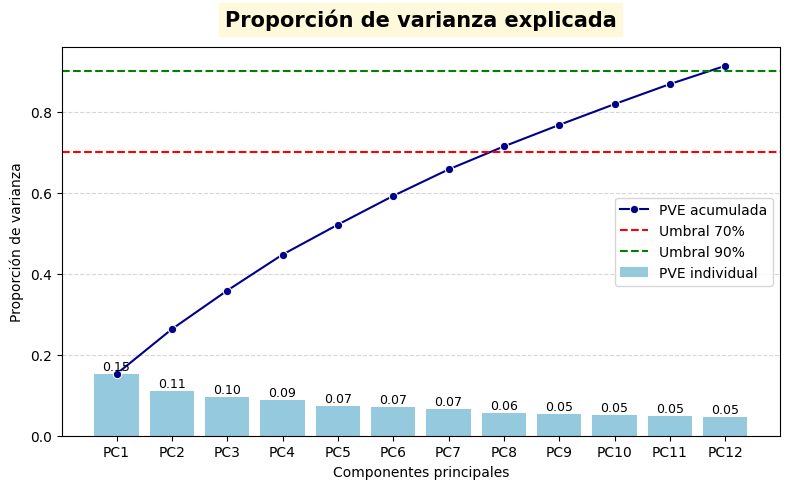

In [57]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='PVE', data=df_varianza, color='skyblue', label='PVE individual')
sns.lineplot(x='Componente', y='PVE acumulada', data=df_varianza, marker='o', color='darkblue', label='PVE acumulada')

plt.axhline(0.7, color='red', linestyle='--', label='Umbral 70%')
plt.axhline(0.9, color='green', linestyle='--', label='Umbral 90%')

for i, v in enumerate(df_varianza['PVE']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=9, color='black')

plt.title("Proporción de varianza explicada", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Proporción de varianza")
plt.xlabel("Componentes principales")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Tercer subconjunto**

In [58]:
tercer_x = X_pca_final

**Extracción de características con LDA**

In [59]:
df["NObeyesdad"] = LabelEncoder().fit_transform(df["NObeyesdad"])
y = df['NObeyesdad']
lda = LDA(n_components=6)
X_lda = lda.fit_transform(X_std, y)

lda_coefficients = pd.DataFrame(
    lda.scalings_,
    columns=['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6']
)

lda_coefficients

,LD1,LD2,LD3,LD4,LD5,LD6
0,-0.630427,-0.877420,0.601437,0.255051,0.208535,-0.355777
1,0.352395,-0.561479,0.006295,-0.163203,0.473917,-0.067922
2,3.108423,-0.076545,0.401417,-0.074431,-0.404020,0.459524
3,0.120143,-0.255349,-0.474038,-0.275011,0.256778,-0.050080
4,-0.012560,0.171014,-0.072421,0.508823,-0.719836,-0.261519
5,0.097690,0.530789,0.381159,-0.014255,0.346992,-0.612322
6,-0.007990,0.410266,0.344525,0.014348,0.088955,-0.343129
7,0.273029,-0.075116,-0.477715,0.456372,0.353450,-0.519643
8,-0.061880,-0.060726,0.140976,0.021063,-0.111904,0.250840
9,-0.085259,0.188918,-0.435275,-0.148228,-0.088275,0.080858


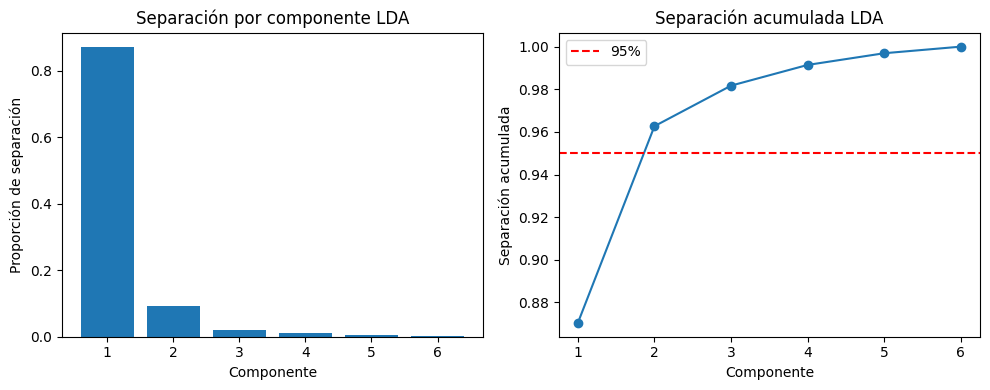

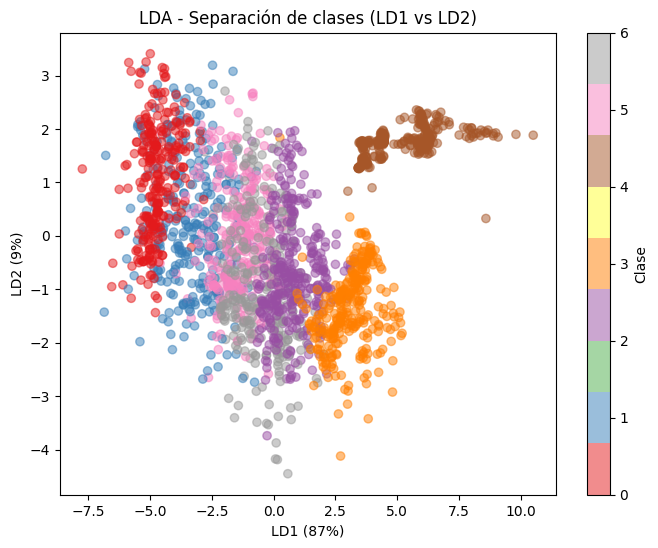

In [60]:
# Gráfica de separación por componente
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, 7), lda.explained_variance_ratio_)
plt.xlabel("Componente")
plt.ylabel("Proporción de separación")
plt.title("Separación por componente LDA")

plt.subplot(1, 2, 2)
plt.plot(range(1, 7), lda.explained_variance_ratio_.cumsum(), marker='o')
plt.axhline(y=0.95, color='red', linestyle='--', label='95%')
plt.xlabel("Componente")
plt.ylabel("Separación acumulada")
plt.title("Separación acumulada LDA")
plt.legend()

plt.tight_layout()
plt.show()

# Scatter plot LD1 vs LD2
y_encoded = LabelEncoder().fit_transform(y)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1],
                      c=y_encoded, cmap='Set1', alpha=0.5)
plt.title("LDA - Separación de clases (LD1 vs LD2)")
plt.xlabel("LD1 (87%)")
plt.ylabel("LD2 (9%)")
plt.colorbar(scatter, label='Clase')
plt.show()

In [61]:
lda_final = LDA(n_components=4)
X_lda = lda_final.fit_transform(X_std, y)

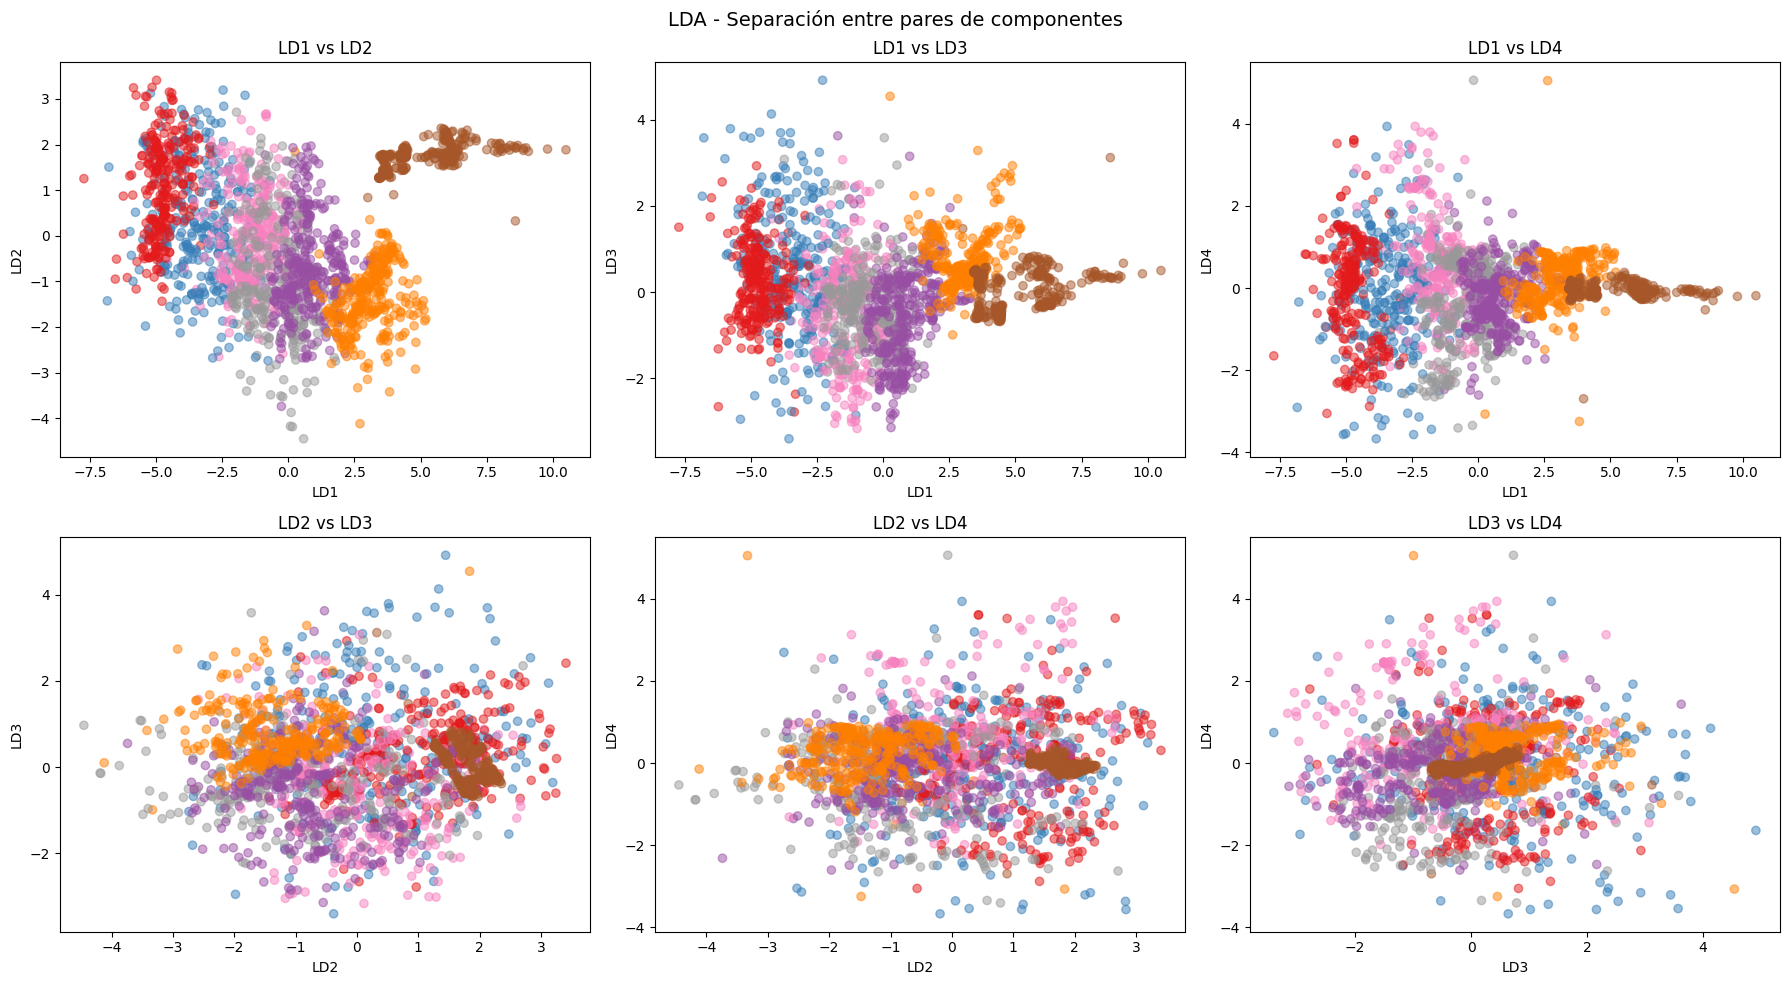

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pares = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
nombres = ['LD1 vs LD2', 'LD1 vs LD3', 'LD1 vs LD4',
           'LD2 vs LD3', 'LD2 vs LD4', 'LD3 vs LD4']

for ax, (i,j), nombre in zip(axes.flatten(), pares, nombres):
    scatter = ax.scatter(X_lda[:, i], X_lda[:, j],
                         c=y_encoded, cmap='Set1', alpha=0.5)
    ax.set_title(nombre)
    ax.set_xlabel(f'LD{i+1}')
    ax.set_ylabel(f'LD{j+1}')

plt.suptitle("LDA - Separación entre pares de componentes", fontsize=14)
plt.tight_layout()
plt.show()

**Cuarto subconjunto**

In [63]:
cuarto_x = X_lda

**Empezamos el proceso para entrenar nuestros modelos**

In [64]:
primer_x = pd.get_dummies(primer_x, drop_first=True)
segundo_x = pd.get_dummies(segundo_x, drop_first=True)

In [65]:
#División de datos de los 4 subconjuntos
X_train1, X_test1, y_train1, y_test1 = train_test_split(primer_x, y, train_size=0.8, random_state=0, shuffle=True)
X_train2, X_test2, y_train2, y_test2 = train_test_split(segundo_x, y, train_size=0.8, random_state=0, shuffle=True)
X_train3, X_test3, y_train3, y_test3 = train_test_split(tercer_x, y, train_size=0.8, random_state=0, shuffle=True)
X_train4, X_test4, y_train4, y_test4 = train_test_split(cuarto_x, y, train_size=0.8, random_state=0, shuffle=True)

In [66]:
#Se escalan los de los dos primeros subconjuntos, los otros ya están transformados por PCA y LDA respectivamente
num_sin_height = [col for col in num if col != 'Height']
scaler = MinMaxScaler()
X_train1[num_sin_height] = scaler.fit_transform(X_train1[num_sin_height])
X_test1[num_sin_height] = scaler.transform(X_test1[num_sin_height])
X_train2[num_sin_height] = scaler.fit_transform(X_train2[num_sin_height])
X_test2[num_sin_height] = scaler.transform(X_test2[num_sin_height])

### **Modelo de Regresión Logística**

Subconjunto: Completo


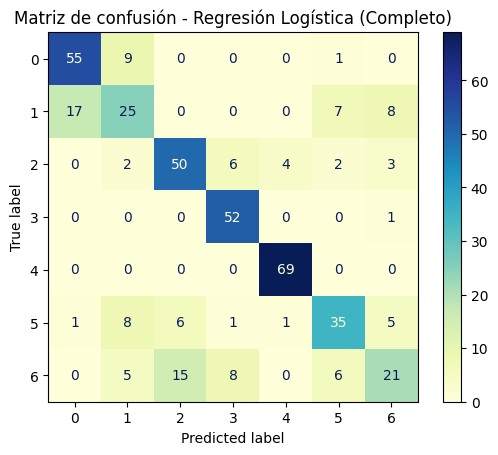

              precision    recall  f1-score   support

           0       0.75      0.85      0.80        65
           1       0.51      0.44      0.47        57
           2       0.70      0.75      0.72        67
           3       0.78      0.98      0.87        53
           4       0.93      1.00      0.97        69
           5       0.69      0.61      0.65        57
           6       0.55      0.38      0.45        55

    accuracy                           0.73       423
   macro avg       0.70      0.72      0.70       423
weighted avg       0.71      0.73      0.71       423

Subconjunto: Filtro


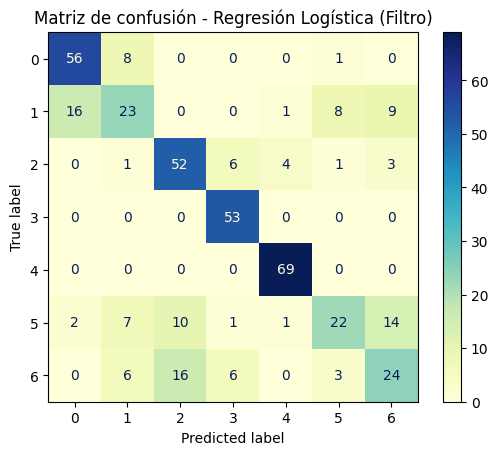

              precision    recall  f1-score   support

           0       0.76      0.86      0.81        65
           1       0.51      0.40      0.45        57
           2       0.67      0.78      0.72        67
           3       0.80      1.00      0.89        53
           4       0.92      1.00      0.96        69
           5       0.63      0.39      0.48        57
           6       0.48      0.44      0.46        55

    accuracy                           0.71       423
   macro avg       0.68      0.69      0.68       423
weighted avg       0.69      0.71      0.69       423

Subconjunto: PCA


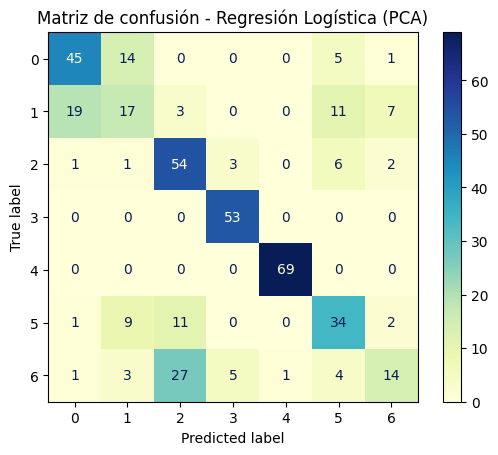

              precision    recall  f1-score   support

           0       0.67      0.69      0.68        65
           1       0.39      0.30      0.34        57
           2       0.57      0.81      0.67        67
           3       0.87      1.00      0.93        53
           4       0.99      1.00      0.99        69
           5       0.57      0.60      0.58        57
           6       0.54      0.25      0.35        55

    accuracy                           0.68       423
   macro avg       0.66      0.66      0.65       423
weighted avg       0.66      0.68      0.66       423

Subconjunto: LDA


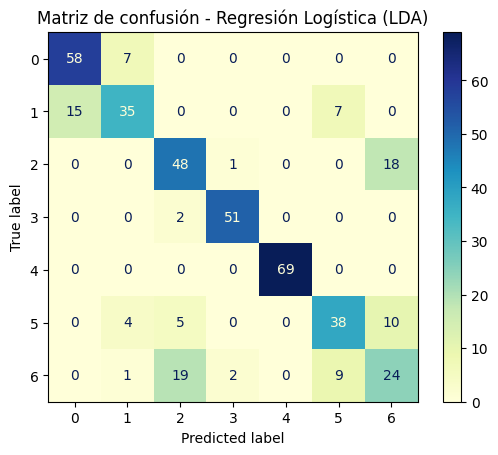

              precision    recall  f1-score   support

           0       0.79      0.89      0.84        65
           1       0.74      0.61      0.67        57
           2       0.65      0.72      0.68        67
           3       0.94      0.96      0.95        53
           4       1.00      1.00      1.00        69
           5       0.70      0.67      0.68        57
           6       0.46      0.44      0.45        55

    accuracy                           0.76       423
   macro avg       0.76      0.76      0.75       423
weighted avg       0.76      0.76      0.76       423



In [67]:
subconjuntos = {
    'Completo': (X_train1, X_test1, y_train1, y_test1),
    'Filtro':   (X_train2, X_test2, y_train2, y_test2),
    'PCA':      (X_train3, X_test3, y_train3, y_test3),
    'LDA':      (X_train4, X_test4, y_train4, y_test4)
}

modelos_lr = []
for nombre, (X_train, X_test, y_train, y_test) in subconjuntos.items():
    modelo_lr = LogisticRegression(random_state=0, max_iter=1000)
    modelo_lr.fit(X_train, y_train)
    y_pred_lr = modelo_lr.predict(X_test)

    print(f"Subconjunto: {nombre}")
    mc_lr = confusion_matrix(y_test, y_pred_lr)
    disp = ConfusionMatrixDisplay(confusion_matrix=mc_lr, display_labels=modelo_lr.classes_)
    disp.plot(cmap='YlGnBu')
    plt.title(f"Matriz de confusión - Regresión Logística ({nombre})")
    plt.show()
    print(classification_report(y_test, y_pred_lr))
    modelos_lr.append(modelo_lr)

### **Encontrar los mejores hiperparámetros con GridSearchCV**

In [68]:
#Modelo con el primer subconjunto (completo) para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

cv = 10

modelo_lr_grid_1 = GridSearchCV(estimator=modelos_lr[0],
                                param_grid=param_grid_lr,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_lr_grid_1.fit(X_train1, y_train1)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.514, test=0.503) f1: (train=0.477, test=0.441) precision: (train=0.554, test=0.442) recall: (train=0.506, test=0.490) total time=   0.2s
[CV 2/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.514, test=0.550) f1: (train=0.474, test=0.522) precision: (train=0.552, test=0.580) recall: (train=0.505, test=0.542) total time=   0.0s
[CV 3/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.525, test=0.485) f1: (train=0.486, test=0.433) precision: (train=0.563, test=0.497) recall: (train=0.516, test=0.468) total time=   0.0s
[CV 4/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.508, test=0.485) f1: (train=0.466, test=0.449) precision: (train=0.542, test=0.531) recall: (train=0.498, test=0.482) total time=   0.0s
[CV 5/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.506, test=0.497) f1: (train=0.467, test=0.44

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [69]:
#Modelo con el segundo subconjunto (filtro) para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

cv = 10

modelo_lr_grid_2 = GridSearchCV(estimator=modelos_lr[1],
                                param_grid=param_grid_lr,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_lr_grid_2.fit(X_train2, y_train2)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.523, test=0.533) f1: (train=0.451, test=0.462) precision: (train=0.465, test=0.477) recall: (train=0.516, test=0.526) total time=   0.0s
[CV 2/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.512, test=0.521) f1: (train=0.429, test=0.434) precision: (train=0.431, test=0.389) recall: (train=0.506, test=0.514) total time=   0.0s
[CV 3/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.510, test=0.497) f1: (train=0.431, test=0.423) precision: (train=0.428, test=0.428) recall: (train=0.505, test=0.491) total time=   0.0s
[CV 4/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.520, test=0.515) f1: (train=0.451, test=0.442) precision: (train=0.463, test=0.480) recall: (train=0.514, test=0.515) total time=   0.0s
[CV 5/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.529, test=0.497) f1: (train=0.463, test=0.41

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [70]:
#Modelo con el tercer subconjunto (PCA) para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

cv = 10

modelo_lr_grid_3 = GridSearchCV(estimator=modelos_lr[2],
                                param_grid=param_grid_lr,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_lr_grid_3.fit(X_train3, y_train3)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.608, test=0.598) f1: (train=0.584, test=0.557) precision: (train=0.608, test=0.565) recall: (train=0.601, test=0.589) total time=   0.0s
[CV 2/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.593, test=0.621) f1: (train=0.565, test=0.600) precision: (train=0.589, test=0.614) recall: (train=0.585, test=0.614) total time=   0.0s
[CV 3/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.604, test=0.580) f1: (train=0.578, test=0.547) precision: (train=0.602, test=0.571) recall: (train=0.598, test=0.567) total time=   0.0s
[CV 4/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.608, test=0.586) f1: (train=0.582, test=0.560) precision: (train=0.602, test=0.598) recall: (train=0.600, test=0.586) total time=   0.0s
[CV 5/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.608, test=0.533) f1: (train=0.586, test=0.50

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [71]:
#Modelo con el cuarto subconjunto (LDA) para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

cv = 10

modelo_lr_grid_4 = GridSearchCV(estimator=modelos_lr[3],
                                param_grid=param_grid_lr,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_lr_grid_4.fit(X_train4, y_train4)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.747, test=0.728) f1: (train=0.734, test=0.708) precision: (train=0.737, test=0.713) recall: (train=0.746, test=0.722) total time=   0.0s
[CV 2/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.742, test=0.769) f1: (train=0.727, test=0.753) precision: (train=0.732, test=0.762) recall: (train=0.740, test=0.769) total time=   0.0s
[CV 3/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.749, test=0.722) f1: (train=0.734, test=0.704) precision: (train=0.739, test=0.711) recall: (train=0.747, test=0.717) total time=   0.0s
[CV 4/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.747, test=0.757) f1: (train=0.732, test=0.742) precision: (train=0.736, test=0.763) recall: (train=0.745, test=0.762) total time=   0.0s
[CV 5/10] END C=0.01, max_iter=500, solver=lbfgs; accuracy: (train=0.747, test=0.728) f1: (train=0.732, test=0.71

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [72]:
modelos_lr_grid = [modelo_lr_grid_1, modelo_lr_grid_2, modelo_lr_grid_3, modelo_lr_grid_4]

for i in modelos_lr_grid:
    resultados = pd.DataFrame(i.cv_results_)
    print(f"Resultados del modelo con subconjunto {modelos_lr_grid.index(i) + 1}")
    display(resultados.filter(regex='(param.*|mean_t|std_t)') \
        .drop(columns='params') \
        .sort_values('mean_test_accuracy', ascending=False) \
        .head(4))

Resultados del modelo con subconjunto 1


,param_C,param_max_iter,param_solver,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
19,100.0,1000,saga,0.823447,0.024678,0.845182,0.003384,0.818403,0.025676,0.840293,0.003547,0.826098,0.022345,0.841975,0.003810,0.821606,0.025109,0.842568,0.003399
17,100.0,500,saga,0.822263,0.025395,0.844656,0.003581,0.817252,0.026390,0.839686,0.003729,0.824930,0.023165,0.841397,0.004023,0.820475,0.025745,0.841998,0.003549
18,100.0,1000,lbfgs,0.822260,0.025135,0.845445,0.003885,0.817141,0.025997,0.840576,0.004024,0.824850,0.022673,0.842247,0.004221,0.820467,0.025602,0.842833,0.003945
16,100.0,500,lbfgs,0.821076,0.024957,0.845511,0.003843,0.815930,0.025904,0.840644,0.003982,0.823547,0.022892,0.842317,0.004176,0.819242,0.025452,0.842890,0.003905


Resultados del modelo con subconjunto 2


,param_C,param_max_iter,param_solver,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
18,100.0,1000,lbfgs,0.776064,0.019442,0.803778,0.004991,0.767174,0.024260,0.796794,0.005150,0.775024,0.024894,0.797391,0.005410,0.772279,0.020768,0.799804,0.005157
16,100.0,500,lbfgs,0.776064,0.019442,0.803778,0.004991,0.767174,0.024260,0.796794,0.005150,0.775024,0.024894,0.797391,0.005410,0.772279,0.020768,0.799804,0.005157
19,100.0,1000,saga,0.776060,0.018747,0.804173,0.004972,0.766709,0.023038,0.797100,0.005086,0.775046,0.023917,0.797674,0.005352,0.772039,0.019967,0.800191,0.005079
17,100.0,500,saga,0.776060,0.018747,0.803910,0.004956,0.766709,0.023038,0.796823,0.005080,0.775046,0.023917,0.797377,0.005337,0.772039,0.019967,0.799932,0.005083


Resultados del modelo con subconjunto 3


,param_C,param_max_iter,param_solver,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
18,100.0,1000,lbfgs,0.653416,0.037270,0.674170,0.006835,0.636436,0.034760,0.658796,0.006961,0.647239,0.041345,0.663999,0.007488,0.646362,0.038983,0.667154,0.006862
16,100.0,500,lbfgs,0.653416,0.037270,0.674170,0.006835,0.636436,0.034760,0.658796,0.006961,0.647239,0.041345,0.663999,0.007488,0.646362,0.038983,0.667154,0.006862
13,10.0,500,saga,0.652226,0.043222,0.671867,0.006024,0.635470,0.042509,0.656515,0.006178,0.643934,0.047541,0.661422,0.006480,0.645547,0.045177,0.665147,0.006225
17,100.0,500,saga,0.652226,0.038145,0.674105,0.006584,0.634950,0.035823,0.658787,0.006763,0.644962,0.042644,0.663894,0.007223,0.645341,0.039701,0.667293,0.006710


Resultados del modelo con subconjunto 4


,param_C,param_max_iter,param_solver,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
8,1.0,500,lbfgs,0.773686,0.021414,0.775606,0.002772,0.765850,0.024936,0.769678,0.003093,0.769427,0.026574,0.769562,0.003201,0.771849,0.024326,0.773759,0.002865
9,1.0,500,saga,0.773686,0.021414,0.775671,0.002839,0.765736,0.024829,0.769760,0.003145,0.769227,0.026425,0.769648,0.003245,0.771849,0.024326,0.773826,0.002930
10,1.0,1000,lbfgs,0.773686,0.021414,0.775606,0.002772,0.765850,0.024936,0.769678,0.003093,0.769427,0.026574,0.769562,0.003201,0.771849,0.024326,0.773759,0.002865
11,1.0,1000,saga,0.773686,0.021414,0.775671,0.002839,0.765736,0.024829,0.769760,0.003145,0.769227,0.026425,0.769648,0.003245,0.771849,0.024326,0.773826,0.002930


In [73]:
print(modelo_lr_grid_1.best_params_)
print(modelo_lr_grid_2.best_params_)
print(modelo_lr_grid_3.best_params_)
print(modelo_lr_grid_4.best_params_)

{'C': 100, 'max_iter': 1000, 'solver': 'saga'}
{'C': 100, 'max_iter': 500, 'solver': 'lbfgs'}
{'C': 100, 'max_iter': 500, 'solver': 'lbfgs'}
{'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}


In [105]:
subconjuntos_items = list(subconjuntos.items())
finales_lr = []
for (nombre, (X_train, X_test, y_train, y_test)), modelo_grid in zip(subconjuntos_items, modelos_lr_grid):
    
    modelo_final = modelo_grid.best_estimator_
    mejor_idx = modelo_grid.cv_results_['mean_test_accuracy'].argmax()
    
    df_resultados = pd.DataFrame([{
        'acc_train': accuracy_score(y_train, modelo_final.predict(X_train)),
        'f1_train': f1_score(y_train, modelo_final.predict(X_train), average='macro'),
        'recall_train': recall_score(y_train, modelo_final.predict(X_train), average='macro'),
        'precision_train': precision_score(y_train, modelo_final.predict(X_train), average='macro'),
        'acc_val': modelo_grid.cv_results_['mean_test_accuracy'][mejor_idx],
        'f1_val': modelo_grid.cv_results_['mean_test_f1'][mejor_idx],
        'recall_val': modelo_grid.cv_results_['mean_test_recall'][mejor_idx],
        'precision_val': modelo_grid.cv_results_['mean_test_precision'][mejor_idx],
        'acc_test': accuracy_score(y_test, modelo_final.predict(X_test)),
        'f1_test': f1_score(y_test, modelo_final.predict(X_test), average='macro'),
        'recall_test': recall_score(y_test, modelo_final.predict(X_test), average='macro'),
        'precision_test': precision_score(y_test, modelo_final.predict(X_test), average='macro'),
        'subconjunto': nombre
    }])
    display(df_resultados)
    finales_lr.append(df_resultados)
    

,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,0.842417,0.837142,0.839699,0.839358,0.823447,0.818403,0.821606,0.826098,0.822695,0.816708,0.81775,0.8181,Completo


,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,0.802725,0.796199,0.798795,0.79694,0.776064,0.767174,0.772279,0.775024,0.801418,0.792537,0.794165,0.793689,Filtro


,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,0.67654,0.661811,0.669548,0.667043,0.653416,0.636436,0.646362,0.647239,0.690307,0.665986,0.678409,0.675475,PCA


,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,0.777251,0.771424,0.775447,0.771666,0.773686,0.76585,0.771849,0.769427,0.763593,0.754437,0.755436,0.756791,LDA


In [106]:
tabla_resultados = pd.DataFrame(columns=['Modelo', 'subconjunto', 'Accuracy', 'Recall', 'F1', 'Precision'])

for i in finales_lr:
    tabla_resultados = pd.concat([tabla_resultados,
                        pd.DataFrame([{
                            'Modelo': 'Regresión Logística',
                            'subconjunto': i.iloc[0]['subconjunto'],
                            'Accuracy': i.iloc[0]['acc_test'],
                            'Recall': i.iloc[0]['recall_test'],
                            'F1': i.iloc[0]['f1_test'],
                            'Precision': i.iloc[0]['precision_test']
                        }])], ignore_index=True)

tabla_resultados.drop_duplicates(inplace=True)
tabla_resultados

,Modelo,subconjunto,Accuracy,Recall,F1,Precision
0,Regresión Logística,Completo,0.822695,0.81775,0.816708,0.8181
1,Regresión Logística,Filtro,0.801418,0.794165,0.792537,0.793689
2,Regresión Logística,PCA,0.690307,0.678409,0.665986,0.675475
3,Regresión Logística,LDA,0.763593,0.755436,0.754437,0.756791


### **KNN (K-Nearest Neighbors)**

Subconjunto: Completo


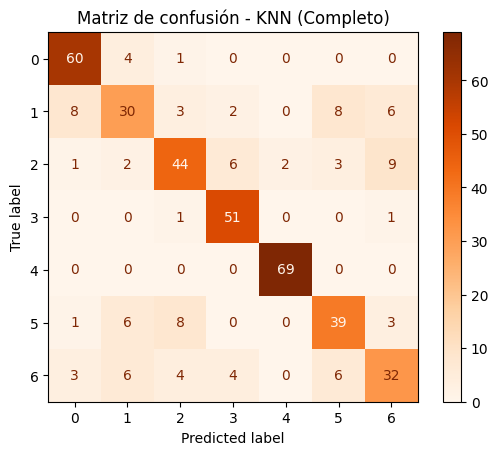

              precision    recall  f1-score   support

           0       0.82      0.92      0.87        65
           1       0.62      0.53      0.57        57
           2       0.72      0.66      0.69        67
           3       0.81      0.96      0.88        53
           4       0.97      1.00      0.99        69
           5       0.70      0.68      0.69        57
           6       0.63      0.58      0.60        55

    accuracy                           0.77       423
   macro avg       0.75      0.76      0.76       423
weighted avg       0.76      0.77      0.76       423

Subconjunto: Filtro


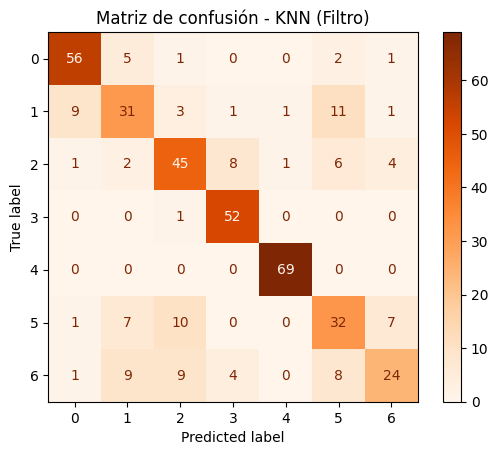

              precision    recall  f1-score   support

           0       0.82      0.86      0.84        65
           1       0.57      0.54      0.56        57
           2       0.65      0.67      0.66        67
           3       0.80      0.98      0.88        53
           4       0.97      1.00      0.99        69
           5       0.54      0.56      0.55        57
           6       0.65      0.44      0.52        55

    accuracy                           0.73       423
   macro avg       0.72      0.72      0.71       423
weighted avg       0.72      0.73      0.72       423

Subconjunto: PCA


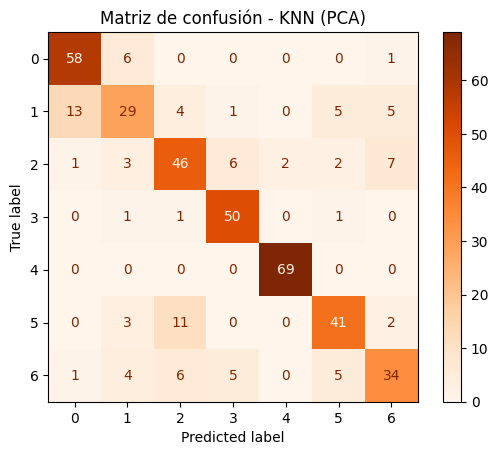

              precision    recall  f1-score   support

           0       0.79      0.89      0.84        65
           1       0.63      0.51      0.56        57
           2       0.68      0.69      0.68        67
           3       0.81      0.94      0.87        53
           4       0.97      1.00      0.99        69
           5       0.76      0.72      0.74        57
           6       0.69      0.62      0.65        55

    accuracy                           0.77       423
   macro avg       0.76      0.77      0.76       423
weighted avg       0.77      0.77      0.77       423

Subconjunto: LDA


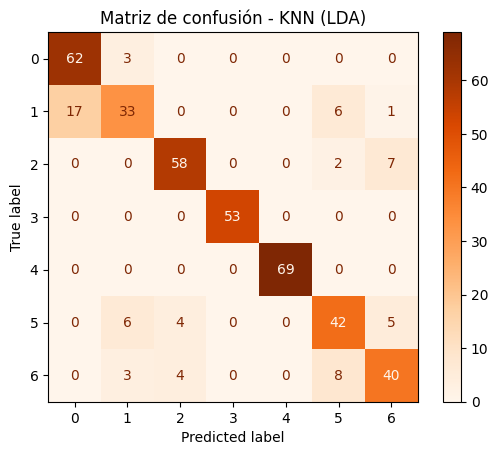

              precision    recall  f1-score   support

           0       0.78      0.95      0.86        65
           1       0.73      0.58      0.65        57
           2       0.88      0.87      0.87        67
           3       1.00      1.00      1.00        53
           4       1.00      1.00      1.00        69
           5       0.72      0.74      0.73        57
           6       0.75      0.73      0.74        55

    accuracy                           0.84       423
   macro avg       0.84      0.84      0.84       423
weighted avg       0.84      0.84      0.84       423



In [76]:
modelos_knn = []
for nombre, (X_train, X_test, y_train, y_test) in subconjuntos.items():
    modelo_knn = KNeighborsClassifier()
    modelo_knn.fit(X_train, y_train)
    y_pred_knn = modelo_knn.predict(X_test)

    print(f"Subconjunto: {nombre}")
    mc_knn = confusion_matrix(y_test, y_pred_knn)
    disp = ConfusionMatrixDisplay(confusion_matrix=mc_knn, display_labels=modelo_knn.classes_)
    disp.plot(cmap='Oranges')
    plt.title(f"Matriz de confusión - KNN ({nombre})")
    plt.show()
    print(classification_report(y_test, y_pred_knn))
    modelos_knn.append(modelo_knn)

### **Encontrar los mejores hiperparámetros con GridSearchCV**

In [77]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = 10

modelo_knn_grid_1 = GridSearchCV(estimator=modelos_knn[0],
                                param_grid=param_grid_knn,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_knn_grid_1.fit(X_train1, y_train1)

Fitting 10 folds for each of 28 candidates, totalling 280 fits
[CV 1/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.877, test=0.757) f1: (train=0.874, test=0.740) precision: (train=0.875, test=0.743) recall: (train=0.875, test=0.751) total time=   0.0s
[CV 2/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.868, test=0.852) f1: (train=0.863, test=0.847) precision: (train=0.865, test=0.850) recall: (train=0.865, test=0.850) total time=   0.0s
[CV 3/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.879, test=0.781) f1: (train=0.875, test=0.770) precision: (train=0.877, test=0.780) recall: (train=0.876, test=0.775) total time=   0.0s
[CV 4/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.873, test=0.799) f1: (train=0.869, test=0.794) precision: (train=0.871, test=0.798) recall: (train=0.871, test=0.797) total time=   0.0s
[CV 5/10] END metric=euclidean, n_neighbors=3, weights=un

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the hig

In [78]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = 10

modelo_knn_grid_2 = GridSearchCV(estimator=modelos_knn[1],
                                param_grid=param_grid_knn,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_knn_grid_2.fit(X_train2, y_train2)

Fitting 10 folds for each of 28 candidates, totalling 280 fits
[CV 1/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.867, test=0.722) f1: (train=0.863, test=0.706) precision: (train=0.866, test=0.715) recall: (train=0.864, test=0.716) total time=   0.0s
[CV 2/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.863, test=0.805) f1: (train=0.859, test=0.799) precision: (train=0.863, test=0.806) recall: (train=0.861, test=0.801) total time=   0.0s
[CV 3/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.870, test=0.716) f1: (train=0.866, test=0.696) precision: (train=0.869, test=0.717) recall: (train=0.867, test=0.707) total time=   0.0s
[CV 4/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.868, test=0.746) f1: (train=0.864, test=0.734) precision: (train=0.866, test=0.737) recall: (train=0.866, test=0.743) total time=   0.0s
[CV 5/10] END metric=euclidean, n_neighbors=3, weights=un

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the hig

In [79]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = 10

modelo_knn_grid_3 = GridSearchCV(estimator=modelos_knn[2],
                                param_grid=param_grid_knn,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_knn_grid_3.fit(X_train3, y_train3)

Fitting 10 folds for each of 28 candidates, totalling 280 fits
[CV 1/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.883, test=0.775) f1: (train=0.879, test=0.763) precision: (train=0.881, test=0.770) recall: (train=0.881, test=0.771) total time=   0.0s
[CV 2/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.878, test=0.805) f1: (train=0.874, test=0.791) precision: (train=0.876, test=0.792) recall: (train=0.876, test=0.800) total time=   0.0s
[CV 3/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.887, test=0.775) f1: (train=0.883, test=0.761) precision: (train=0.885, test=0.768) recall: (train=0.885, test=0.767) total time=   0.0s
[CV 4/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.880, test=0.817) f1: (train=0.876, test=0.812) precision: (train=0.879, test=0.813) recall: (train=0.878, test=0.819) total time=   0.0s
[CV 5/10] END metric=euclidean, n_neighbors=3, weights=un

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the hig

In [80]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = 10

modelo_knn_grid_4 = GridSearchCV(estimator=modelos_knn[3],
                                param_grid=param_grid_knn,
                                cv=cv,
                                scoring=scoring,
                                refit='accuracy',
                                return_train_score=True,
                                verbose=4)

modelo_knn_grid_4.fit(X_train4, y_train4)

Fitting 10 folds for each of 28 candidates, totalling 280 fits
[CV 1/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.895, test=0.805) f1: (train=0.892, test=0.797) precision: (train=0.892, test=0.797) recall: (train=0.893, test=0.803) total time=   0.0s
[CV 2/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.889, test=0.864) f1: (train=0.885, test=0.862) precision: (train=0.885, test=0.864) recall: (train=0.886, test=0.863) total time=   0.0s
[CV 3/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.893, test=0.822) f1: (train=0.889, test=0.816) precision: (train=0.889, test=0.822) recall: (train=0.891, test=0.816) total time=   0.0s
[CV 4/10] END metric=euclidean, n_neighbors=3, weights=uniform; accuracy: (train=0.895, test=0.858) f1: (train=0.892, test=0.854) precision: (train=0.892, test=0.860) recall: (train=0.893, test=0.859) total time=   0.0s
[CV 5/10] END metric=euclidean, n_neighbors=3, weights=un

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the hig

In [81]:
modelos_knn_grid = [modelo_knn_grid_1, modelo_knn_grid_2, modelo_knn_grid_3, modelo_knn_grid_4]

for i in modelos_knn_grid:
    resultados = pd.DataFrame(i.cv_results_)
    print(f"Resultados del modelo con subconjunto {modelos_knn_grid.index(i) + 1}")
    display(resultados.filter(regex='(param.*|mean_t|std_t)') \
        .drop(columns='params') \
        .sort_values('mean_test_accuracy', ascending=False) \
        .head(4))

Resultados del modelo con subconjunto 1


,param_metric,param_n_neighbors,param_weights,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
15,manhattan,3,distance,0.829410,0.034592,1.000000,0.000000,0.822939,0.035763,1.000000,0.000000,0.826146,0.037128,1.000000,0.000000,0.826471,0.034525,1.000000,0.000000
17,manhattan,5,distance,0.827025,0.035339,1.000000,0.000000,0.821771,0.035292,1.000000,0.000000,0.825931,0.035383,1.000000,0.000000,0.824331,0.034780,1.000000,0.000000
19,manhattan,7,distance,0.818146,0.032005,1.000000,0.000000,0.811878,0.033037,1.000000,0.000000,0.814646,0.034174,1.000000,0.000000,0.815581,0.031686,1.000000,0.000000
14,manhattan,3,uniform,0.809869,0.037599,0.898104,0.002639,0.801936,0.038608,0.895113,0.002829,0.807448,0.039688,0.896823,0.002991,0.805806,0.036551,0.895808,0.002647


Resultados del modelo con subconjunto 2


,param_metric,param_n_neighbors,param_weights,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
15,manhattan,3,distance,0.826426,0.033564,1.0,0.0,0.822482,0.034625,1.0,0.0,0.826417,0.035562,1.0,0.0,0.823152,0.034041,1.0,0.0
17,manhattan,5,distance,0.818146,0.030197,1.0,0.0,0.812280,0.031957,1.0,0.0,0.815616,0.033149,1.0,0.0,0.814801,0.030799,1.0,0.0
19,manhattan,7,distance,0.815772,0.025076,1.0,0.0,0.810008,0.026993,1.0,0.0,0.812517,0.028176,1.0,0.0,0.812864,0.025683,1.0,0.0
21,manhattan,9,distance,0.814011,0.027097,1.0,0.0,0.807021,0.028305,1.0,0.0,0.810055,0.029467,1.0,0.0,0.810865,0.027205,1.0,0.0


Resultados del modelo con subconjunto 3


,param_metric,param_n_neighbors,param_weights,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
15,manhattan,3,distance,0.802138,0.021483,1.0,0.0,0.791256,0.022551,1.0,0.0,0.796989,0.026097,1.0,0.0,0.799879,0.021735,1.0,0.0
1,euclidean,3,distance,0.798588,0.029071,1.0,0.0,0.788426,0.028593,1.0,0.0,0.796563,0.031033,1.0,0.0,0.797109,0.028597,1.0,0.0
3,euclidean,5,distance,0.796795,0.032497,1.0,0.0,0.785544,0.033914,1.0,0.0,0.792870,0.036248,1.0,0.0,0.794839,0.032582,1.0,0.0
17,manhattan,5,distance,0.790871,0.029225,1.0,0.0,0.779931,0.031240,1.0,0.0,0.786288,0.031411,1.0,0.0,0.789074,0.029166,1.0,0.0


Resultados del modelo con subconjunto 4


,param_metric,param_n_neighbors,param_weights,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
17,manhattan,5,distance,0.843016,0.025662,1.0,0.0,0.836578,0.026625,1.0,0.0,0.842063,0.024545,1.0,0.0,0.841057,0.025794,1.0,0.0
23,manhattan,11,distance,0.842424,0.020307,1.0,0.0,0.835457,0.021535,1.0,0.0,0.839691,0.022250,1.0,0.0,0.840171,0.021440,1.0,0.0
19,manhattan,7,distance,0.840649,0.019811,1.0,0.0,0.833582,0.020732,1.0,0.0,0.838607,0.020838,1.0,0.0,0.838493,0.020089,1.0,0.0
21,manhattan,9,distance,0.840642,0.022352,1.0,0.0,0.833566,0.024486,1.0,0.0,0.837350,0.023685,1.0,0.0,0.838137,0.023577,1.0,0.0


In [82]:
print(modelo_knn_grid_1.best_params_)
print(modelo_knn_grid_2.best_params_)
print(modelo_knn_grid_3.best_params_)
print(modelo_knn_grid_4.best_params_)

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


In [110]:
subconjuntos_items = list(subconjuntos.items())
finales_knn = []

for (nombre, (X_train, X_test, y_train, y_test)), modelo_grid in zip(subconjuntos_items, modelos_knn_grid):
    
    modelo_final = modelo_grid.best_estimator_
    mejor_idx = modelo_grid.cv_results_['mean_test_accuracy'].argmax()
    
    df_resultados = pd.DataFrame([{
        'acc_train': accuracy_score(y_train, modelo_final.predict(X_train)),
        'f1_train': f1_score(y_train, modelo_final.predict(X_train), average='macro'),
        'recall_train': recall_score(y_train, modelo_final.predict(X_train), average='macro'),
        'precision_train': precision_score(y_train, modelo_final.predict(X_train), average='macro'),
        'acc_val': modelo_grid.cv_results_['mean_test_accuracy'][mejor_idx],
        'f1_val': modelo_grid.cv_results_['mean_test_f1'][mejor_idx],
        'recall_val': modelo_grid.cv_results_['mean_test_recall'][mejor_idx],
        'precision_val': modelo_grid.cv_results_['mean_test_precision'][mejor_idx],
        'acc_test': accuracy_score(y_test, modelo_final.predict(X_test)),
        'f1_test': f1_score(y_test, modelo_final.predict(X_test), average='macro'),
        'recall_test': recall_score(y_test, modelo_final.predict(X_test), average='macro'),
        'precision_test': precision_score(y_test, modelo_final.predict(X_test), average='macro'),
        'subconjunto': nombre
    }])
    display(df_resultados)
    finales_knn.append(df_resultados)

,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,1.0,1.0,1.0,1.0,0.82941,0.822939,0.826471,0.826146,0.825059,0.819088,0.82032,0.819422,Completo


,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,1.0,1.0,1.0,1.0,0.826426,0.822482,0.823152,0.826417,0.825059,0.819168,0.820601,0.820282,Filtro


,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,1.0,1.0,1.0,1.0,0.802138,0.791256,0.799879,0.796989,0.780142,0.767968,0.774899,0.767221,PCA


,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test,subconjunto
0,1.0,1.0,1.0,1.0,0.843016,0.836578,0.841057,0.842063,0.858156,0.852324,0.853439,0.854788,LDA


In [111]:
for i in finales_knn:
    tabla_resultados = pd.concat([tabla_resultados,
                        pd.DataFrame([{
                            'Modelo': 'KNN',
                            'subconjunto': i.iloc[0]['subconjunto'],
                            'Accuracy': i.iloc[0]['acc_test'],
                            'Recall': i.iloc[0]['recall_test'],
                            'F1': i.iloc[0]['f1_test'],
                            'Precision': i.iloc[0]['precision_test']
                        }])], ignore_index=True)

tabla_resultados.drop_duplicates(inplace=True)
tabla_resultados

,Modelo,subconjunto,Accuracy,Recall,F1,Precision
0,Regresión Logística,Completo,0.822695,0.81775,0.816708,0.8181
1,Regresión Logística,Filtro,0.801418,0.794165,0.792537,0.793689
2,Regresión Logística,PCA,0.690307,0.678409,0.665986,0.675475
3,Regresión Logística,LDA,0.763593,0.755436,0.754437,0.756791
4,KNN,Completo,0.825059,0.82032,0.819088,0.819422
5,KNN,Filtro,0.825059,0.820601,0.819168,0.820282
6,KNN,PCA,0.780142,0.774899,0.767968,0.767221
7,KNN,LDA,0.858156,0.853439,0.852324,0.854788


### **Modelos de ensamble basados en árboles**

**Random Forest**

In [127]:
tabla_mejores = []
for nombre, (X_train, X_test, y_train, y_test) in subconjuntos.items():

    resultados = []
    for trees in range(10, 101, 10):
        for criterio in ('gini', 'entropy'):
            modelo = RandomForestClassifier(n_estimators=trees, criterion=criterio,
                                            min_samples_leaf=3, random_state=0)
            modelo.fit(X_train, y_train)
            acc_test = accuracy_score(y_test, modelo.predict(X_test))
            acc_train = accuracy_score(y_train, modelo.predict(X_train))
            resultados.append({'trees': trees, 'criterion': criterio,
                                'acc_train': acc_train, 'acc_test': acc_test, 'subconjunto': nombre})

    df_res = pd.DataFrame(resultados)
    mejor_resultado = df_res.sort_values(['acc_test', 'trees'], ascending=[False, True]).iloc[0]
    tabla_mejores.append(mejor_resultado)
    display(df_res.sort_values(['acc_test', 'trees'], ascending=[False, True]))

,trees,criterion,acc_train,acc_test,subconjunto
6,40,gini,0.974526,0.917258,Completo
10,60,gini,0.976303,0.917258,Completo
15,80,entropy,0.979858,0.917258,Completo
17,90,entropy,0.978081,0.917258,Completo
4,30,gini,0.974526,0.912530,Completo
12,70,gini,0.975118,0.912530,Completo
7,40,entropy,0.978081,0.910165,Completo
8,50,gini,0.973934,0.910165,Completo
11,60,entropy,0.977488,0.910165,Completo
13,70,entropy,0.978673,0.910165,Completo


,trees,criterion,acc_train,acc_test,subconjunto
9,50,entropy,0.977488,0.910165,Filtro
12,70,gini,0.976303,0.910165,Filtro
13,70,entropy,0.982820,0.910165,Filtro
11,60,entropy,0.979858,0.907801,Filtro
4,30,gini,0.966825,0.903073,Filtro
14,80,gini,0.976896,0.903073,Filtro
15,80,entropy,0.984597,0.903073,Filtro
5,30,entropy,0.976303,0.900709,Filtro
7,40,entropy,0.978673,0.900709,Filtro
18,100,gini,0.977488,0.900709,Filtro


,trees,criterion,acc_train,acc_test,subconjunto
10,60,gini,0.969787,0.803783,PCA
12,70,gini,0.970379,0.799054,PCA
18,100,gini,0.972156,0.799054,PCA
8,50,gini,0.968602,0.796690,PCA
14,80,gini,0.970379,0.796690,PCA
16,90,gini,0.971564,0.796690,PCA
4,30,gini,0.963863,0.787234,PCA
6,40,gini,0.966232,0.787234,PCA
13,70,entropy,0.976896,0.787234,PCA
2,20,gini,0.959123,0.780142,PCA


,trees,criterion,acc_train,acc_test,subconjunto
19,100,entropy,0.957346,0.848700,LDA
16,90,gini,0.954384,0.846336,LDA
15,80,entropy,0.956161,0.843972,LDA
4,30,gini,0.945498,0.841608,LDA
18,100,gini,0.951422,0.841608,LDA
2,20,gini,0.942536,0.839243,LDA
8,50,gini,0.952014,0.839243,LDA
14,80,gini,0.951422,0.839243,LDA
17,90,entropy,0.956161,0.839243,LDA
5,30,entropy,0.950829,0.836879,LDA


**Visualización de cada uno**

trees               100
criterion       entropy
acc_train       0.98282
acc_test       0.910165
subconjunto    Completo
Name: 19, dtype: object


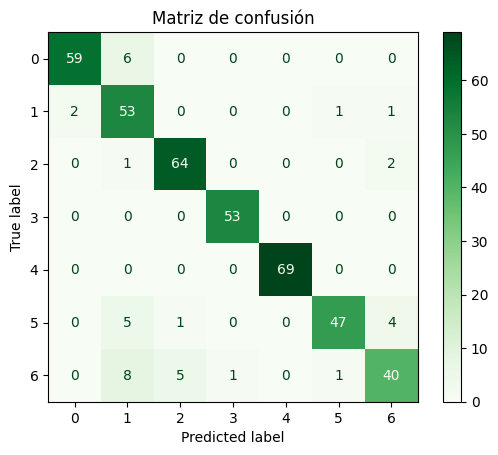

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        65
           1       0.73      0.93      0.82        57
           2       0.91      0.96      0.93        67
           3       0.98      1.00      0.99        53
           4       1.00      1.00      1.00        69
           5       0.96      0.82      0.89        57
           6       0.85      0.73      0.78        55

    accuracy                           0.91       423
   macro avg       0.91      0.91      0.91       423
weighted avg       0.92      0.91      0.91       423



In [114]:
#Conjunto completo
mejor = tabla_mejores[0]
print(mejor)
mejor_modelo_rf_1 = RandomForestClassifier(n_estimators=int(mejor['trees']),criterion=mejor['criterion'], min_samples_leaf=3, random_state=0)
mejor_modelo_rf_1.fit(X_train1, y_train1)
y_pred_final_1 = mejor_modelo_rf_1.predict(X_test1)

mc = confusion_matrix(y_test1, y_pred_final_1)
disp = ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=mejor_modelo_rf_1.classes_)
disp.plot(cmap='Greens')
plt.title("Matriz de confusión")
plt.show()
print(classification_report(y_test1, y_pred_final_1))

trees                80
criterion       entropy
acc_train      0.984597
acc_test       0.903073
subconjunto      Filtro
Name: 15, dtype: object


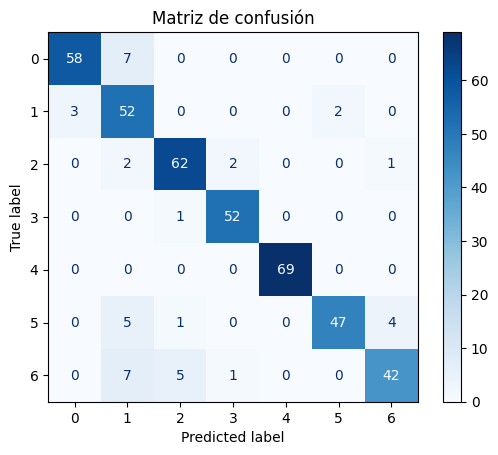

              precision    recall  f1-score   support

           0       0.95      0.89      0.92        65
           1       0.71      0.91      0.80        57
           2       0.90      0.93      0.91        67
           3       0.95      0.98      0.96        53
           4       1.00      1.00      1.00        69
           5       0.96      0.82      0.89        57
           6       0.89      0.76      0.82        55

    accuracy                           0.90       423
   macro avg       0.91      0.90      0.90       423
weighted avg       0.91      0.90      0.90       423



In [115]:
#Subconjunto filtro
mejor = tabla_mejores[1]
print(mejor)
mejor_modelo_rf_2 = RandomForestClassifier(n_estimators=int(mejor['trees']),criterion=mejor['criterion'], min_samples_leaf=3, random_state=0)
mejor_modelo_rf_2.fit(X_train2, y_train2)
y_pred_final_2 = mejor_modelo_rf_2.predict(X_test2)

mc = confusion_matrix(y_test2, y_pred_final_2)
disp = ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=mejor_modelo_rf_2.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión")
plt.show()
print(classification_report(y_test2, y_pred_final_2))

trees                90
criterion       entropy
acc_train      0.979265
acc_test       0.768322
subconjunto         PCA
Name: 17, dtype: object


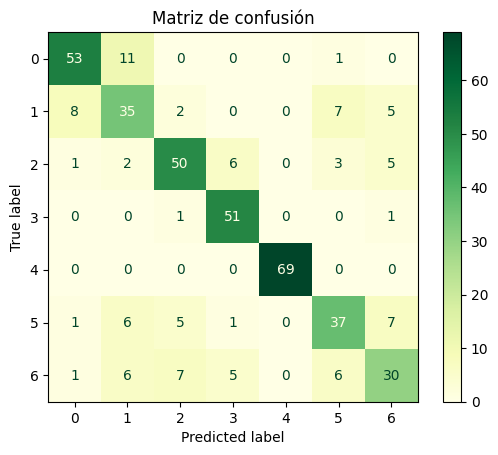

              precision    recall  f1-score   support

           0       0.83      0.82      0.82        65
           1       0.58      0.61      0.60        57
           2       0.77      0.75      0.76        67
           3       0.81      0.96      0.88        53
           4       1.00      1.00      1.00        69
           5       0.69      0.65      0.67        57
           6       0.62      0.55      0.58        55

    accuracy                           0.77       423
   macro avg       0.76      0.76      0.76       423
weighted avg       0.77      0.77      0.77       423



In [116]:
#Subconjunto PCA
mejor = tabla_mejores[2]
print(mejor)
mejor_modelo_rf_3 = RandomForestClassifier(n_estimators=int(mejor['trees']),criterion=mejor['criterion'], min_samples_leaf=3, random_state=0)
mejor_modelo_rf_3.fit(X_train3, y_train3)
y_pred_final_3 = mejor_modelo_rf_3.predict(X_test3)

mc = confusion_matrix(y_test3, y_pred_final_3)
disp = ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=mejor_modelo_rf_3.classes_)
disp.plot(cmap='YlGn')
plt.title("Matriz de confusión")
plt.show()
print(classification_report(y_test3, y_pred_final_3))

trees                60
criterion       entropy
acc_train      0.957938
acc_test       0.832151
subconjunto         LDA
Name: 11, dtype: object


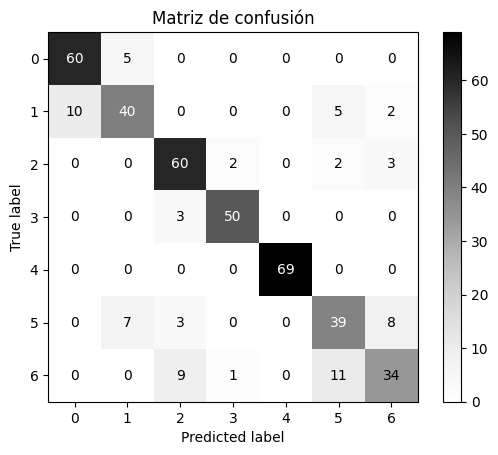

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        65
           1       0.77      0.70      0.73        57
           2       0.80      0.90      0.85        67
           3       0.94      0.94      0.94        53
           4       1.00      1.00      1.00        69
           5       0.68      0.68      0.68        57
           6       0.72      0.62      0.67        55

    accuracy                           0.83       423
   macro avg       0.83      0.82      0.82       423
weighted avg       0.83      0.83      0.83       423



In [117]:
#Subconjunto LDA
mejor = tabla_mejores[3]
print(mejor)
mejor_modelo_rf_4 = RandomForestClassifier(n_estimators=int(mejor['trees']),criterion=mejor['criterion'], min_samples_leaf=3, random_state=0)
mejor_modelo_rf_4.fit(X_train4, y_train4)
y_pred_final_4 = mejor_modelo_rf_4.predict(X_test4)

mc = confusion_matrix(y_test4, y_pred_final_4)
disp = ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=mejor_modelo_rf_4.classes_)
disp.plot(cmap='Greys')
plt.title("Matriz de confusión")
plt.show()
print(classification_report(y_test4, y_pred_final_4))

In [118]:
y_pred_total = [y_pred_final_1, y_pred_final_2, y_pred_final_3, y_pred_final_4]
y_test_total = [y_test1, y_test2, y_test3, y_test4]
for i in range(4):
    print(f"Validación sin ninguna técnica del modelo {i+1} ({tabla_mejores[i]['subconjunto']}):")
    print(f"Accuracy test: {accuracy_score(y_test_total[i], y_pred_total[i]):.4f}")
    print(f"F1 test:       {f1_score(y_test_total[i], y_pred_total[i], average='macro'):.4f}")
    print(f"Recall test:   {recall_score(y_test_total[i], y_pred_total[i], average='macro'):.4f}")
    print(f"Precision test: {precision_score(y_test_total[i], y_pred_total[i], average='macro'):.4f}")
    print("-" * 40)

Validación sin ninguna técnica del modelo 1 (Completo):
Accuracy test: 0.9102
F1 test:       0.9069
Recall test:   0.9064
Precision test: 0.9142
----------------------------------------
Validación sin ninguna técnica del modelo 2 (Filtro):
Accuracy test: 0.9031
F1 test:       0.9008
Recall test:   0.8999
Precision test: 0.9086
----------------------------------------
Validación sin ninguna técnica del modelo 3 (PCA):
Accuracy test: 0.7683
F1 test:       0.7580
Recall test:   0.7618
Precision test: 0.7572
----------------------------------------
Validación sin ninguna técnica del modelo 4 (LDA):
Accuracy test: 0.8322
F1 test:       0.8232
Recall test:   0.8237
Precision test: 0.8253
----------------------------------------


**Validación con cross validation**

In [121]:
X_train = [X_train1, X_train2, X_train3, X_train4]
X_test = [X_test1, X_test2, X_test3, X_test4]
mejores_modelos_rf = [mejor_modelo_rf_1, mejor_modelo_rf_2, mejor_modelo_rf_3, mejor_modelo_rf_4]
y_train = [y_train1, y_train2, y_train3, y_train4]
y_test = [y_test1, y_test2, y_test3, y_test4]


In [122]:
finales = []
for i in range(4):
    cv = 21
    scoring = ['accuracy', 'recall_macro', 'f1_macro', 'precision_macro']

    entries = []
    accuracies = cross_validate(mejores_modelos_rf[i], X_train[i], y_train[i], cv=cv, scoring=scoring)

    cv_df = pd.DataFrame({
        'fold_idx': range(cv),
        'accuracy':  accuracies['test_accuracy'],
        'recall':    accuracies['test_recall_macro'],
        'f1':        accuracies['test_f1_macro'],
        'precision': accuracies['test_precision_macro'],
        'subconjunto': tabla_mejores[i]['subconjunto']
    })
    finales.append(cv_df)
    print(cv_df)
    print("-" * 60)

    fold_idx  accuracy    recall        f1  precision subconjunto
0          0  0.888889  0.894094  0.889011   0.894471    Completo
1          1  0.950617  0.951814  0.950451   0.956401    Completo
2          2  0.876543  0.870130  0.859371   0.865930    Completo
3          3  0.913580  0.913358  0.913314   0.920006    Completo
4          4  0.901235  0.898052  0.900322   0.910965    Completo
5          5  0.913580  0.915121  0.914921   0.937675    Completo
6          6  0.925926  0.922944  0.923583   0.925108    Completo
7          7  0.950617  0.946753  0.947031   0.957614    Completo
8          8  0.937500  0.933766  0.937455   0.955357    Completo
9          9  0.862500  0.860111  0.862855   0.878022    Completo
10        10  0.925000  0.919481  0.923887   0.939394    Completo
11        11  0.925000  0.926240  0.927400   0.936630    Completo
12        12  0.950000  0.950050  0.948986   0.950749    Completo
13        13  0.900000  0.899184  0.900181   0.910256    Completo
14        

In [123]:
resumen_rf = []

for i in range(4):
    y_pred_train = mejores_modelos_rf[i].predict(X_train[i])
    y_pred_test = mejores_modelos_rf[i].predict(X_test[i])
    
    resumen_rf.append({
        'subconjunto': tabla_mejores[i]['subconjunto'],
        'acc_train': accuracy_score(y_train[i], y_pred_train),
        'f1_train': f1_score(y_train[i], y_pred_train, average='macro'),
        'recall_train': recall_score(y_train[i], y_pred_train, average='macro'),
        'precision_train': precision_score(y_train[i], y_pred_train, average='macro'),
        'acc_val': finales[i]['accuracy'].mean(),
        'f1_val': finales[i]['f1'].mean(),
        'recall_val': finales[i]['recall'].mean(),
        'precision_val': finales[i]['precision'].mean(),
        'acc_test': accuracy_score(y_test[i], y_pred_test),
        'f1_test': f1_score(y_test[i], y_pred_test, average='macro'),
        'recall_test': recall_score(y_test[i], y_pred_test, average='macro'),
        'precision_test': precision_score(y_test[i], y_pred_test, average='macro'),
    })

pd.DataFrame(resumen_rf)

,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,Completo,0.982820,0.982472,0.982281,0.983544,0.923618,0.921901,0.922111,0.929587,0.910165,0.906851,0.906368,0.914179
1,Filtro,0.984597,0.984257,0.983886,0.985286,0.907650,0.905624,0.906352,0.915718,0.903073,0.900812,0.899899,0.908565
2,PCA,0.979265,0.979262,0.979575,0.979228,0.809289,0.805017,0.807067,0.814120,0.768322,0.758010,0.761790,0.757200
3,LDA,0.957938,0.956539,0.956866,0.956454,0.828167,0.821747,0.824230,0.830754,0.832151,0.823168,0.823735,0.825341


In [124]:
for i in range(4):
    tabla_resultados = pd.concat([tabla_resultados,
                       pd.DataFrame([{'Modelo': 'Random forest',
                                      'subconjunto': finales[i]['subconjunto'].iloc[0],
                                      'Accuracy': finales[i]['accuracy'].mean().__round__(4),
                                      'Recall': finales[i]['recall'].mean().__round__(4),
                                      'F1': finales[i]['f1'].mean().__round__(4),
                                      'Precision': finales[i]['precision'].mean().__round__(4)}])]
                      , ignore_index=True)
tabla_resultados

,Modelo,subconjunto,Accuracy,Recall,F1,Precision
0,Regresión Logística,Completo,0.822695,0.81775,0.816708,0.8181
1,Regresión Logística,Filtro,0.801418,0.794165,0.792537,0.793689
2,Regresión Logística,PCA,0.690307,0.678409,0.665986,0.675475
3,Regresión Logística,LDA,0.763593,0.755436,0.754437,0.756791
4,KNN,Completo,0.825059,0.82032,0.819088,0.819422
5,KNN,Filtro,0.825059,0.820601,0.819168,0.820282
6,KNN,PCA,0.780142,0.774899,0.767968,0.767221
7,KNN,LDA,0.858156,0.853439,0.852324,0.854788
8,Random forest,Completo,0.9236,0.9221,0.9219,0.9296
9,Random forest,Filtro,0.9076,0.9064,0.9056,0.9157


**Gradient Boosting**

Subconjunto: Completo


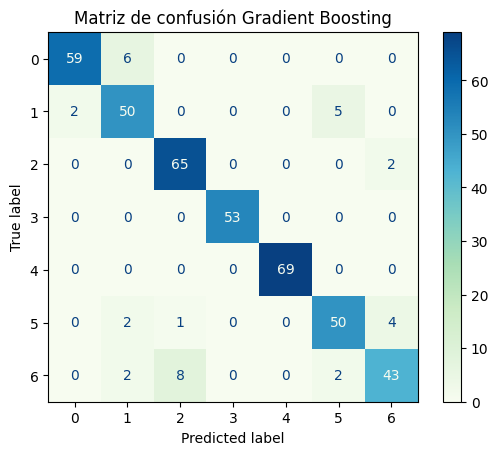

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        65
           1       0.83      0.88      0.85        57
           2       0.88      0.97      0.92        67
           3       1.00      1.00      1.00        53
           4       1.00      1.00      1.00        69
           5       0.88      0.88      0.88        57
           6       0.88      0.78      0.83        55

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.92      0.92      0.92       423

Subconjunto: Filtro


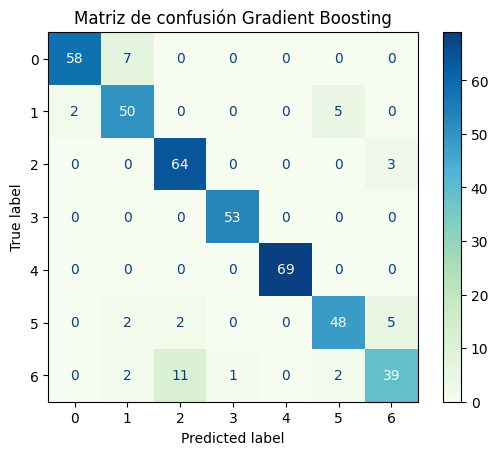

              precision    recall  f1-score   support

           0       0.97      0.89      0.93        65
           1       0.82      0.88      0.85        57
           2       0.83      0.96      0.89        67
           3       0.98      1.00      0.99        53
           4       1.00      1.00      1.00        69
           5       0.87      0.84      0.86        57
           6       0.83      0.71      0.76        55

    accuracy                           0.90       423
   macro avg       0.90      0.90      0.90       423
weighted avg       0.90      0.90      0.90       423

Subconjunto: PCA


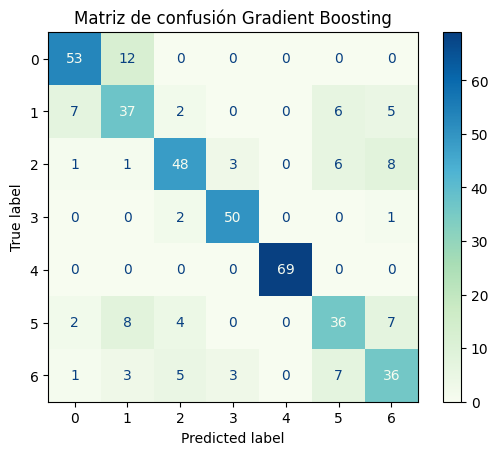

              precision    recall  f1-score   support

           0       0.83      0.82      0.82        65
           1       0.61      0.65      0.63        57
           2       0.79      0.72      0.75        67
           3       0.89      0.94      0.92        53
           4       1.00      1.00      1.00        69
           5       0.65      0.63      0.64        57
           6       0.63      0.65      0.64        55

    accuracy                           0.78       423
   macro avg       0.77      0.77      0.77       423
weighted avg       0.78      0.78      0.78       423

Subconjunto: LDA


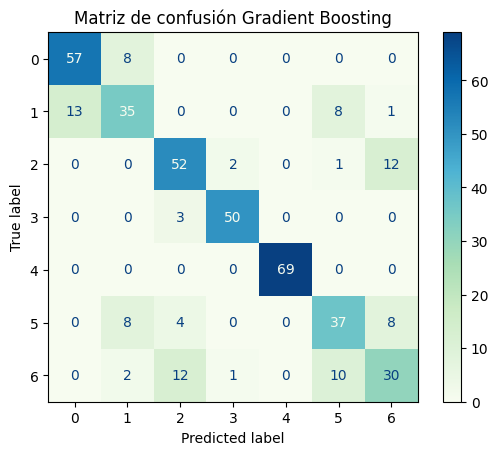

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        65
           1       0.66      0.61      0.64        57
           2       0.73      0.78      0.75        67
           3       0.94      0.94      0.94        53
           4       1.00      1.00      1.00        69
           5       0.66      0.65      0.65        57
           6       0.59      0.55      0.57        55

    accuracy                           0.78       423
   macro avg       0.77      0.77      0.77       423
weighted avg       0.78      0.78      0.78       423



In [128]:
modelos = []
for nombre, (X_train, X_test, y_train, y_test) in subconjuntos.items():
    modelo_gb = GradientBoostingClassifier(min_samples_leaf=3, random_state=0)
    modelo_gb.fit(X_train, y_train)
    y_pred_gb = modelo_gb.predict(X_test)

    print(f"Subconjunto: {nombre}")
    mc_gb = confusion_matrix(y_test, y_pred_gb)
    disp = ConfusionMatrixDisplay(confusion_matrix=mc_gb, display_labels=modelo_gb.classes_)
    disp.plot(cmap='GnBu')
    plt.title("Matriz de confusión Gradient Boosting")
    plt.show()
    print(classification_report(y_test, y_pred_gb))
    modelos.append(modelo_gb)

**Encontrar los mejores hiperparámetros con GridSearchCV**

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
grid_parametros = {'learning_rate': [0.01, 0.1, 0.5],
                   'n_estimators': [50, 100, 150]}

cv = 10

modelo_gb_grid_1 = GridSearchCV(estimator=modelos[0],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_gb_grid_1.fit(X_train1, y_train1)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV 1/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.775, test=0.728) f1: (train=0.765, test=0.715) precision: (train=0.777, test=0.740) recall: (train=0.771, test=0.722) total time=   0.8s
[CV 2/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.785, test=0.728) f1: (train=0.781, test=0.717) precision: (train=0.783, test=0.722) recall: (train=0.784, test=0.725) total time=   0.7s
[CV 3/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.776, test=0.734) f1: (train=0.768, test=0.718) precision: (train=0.775, test=0.724) recall: (train=0.772, test=0.727) total time=   0.6s
[CV 4/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.779, test=0.716) f1: (train=0.772, test=0.709) precision: (train=0.779, test=0.716) recall: (train=0.776, test=0.712) total time=   0.6s
[CV 5/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.786, test=0.728) f1: (train=0.779, test=0

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
grid_parametros = {'learning_rate': [0.01, 0.1, 0.5],
                   'n_estimators': [50, 100, 150]}

cv = 10

modelo_gb_grid_2 = GridSearchCV(estimator=modelos[1],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_gb_grid_2.fit(X_train2, y_train2)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV 1/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.775, test=0.734) f1: (train=0.767, test=0.717) precision: (train=0.784, test=0.760) recall: (train=0.770, test=0.723) total time=   1.1s
[CV 2/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.781, test=0.728) f1: (train=0.774, test=0.715) precision: (train=0.784, test=0.724) recall: (train=0.778, test=0.722) total time=   0.7s
[CV 3/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.768, test=0.728) f1: (train=0.752, test=0.702) precision: (train=0.768, test=0.713) recall: (train=0.762, test=0.719) total time=   0.7s
[CV 4/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.773, test=0.716) f1: (train=0.765, test=0.709) precision: (train=0.773, test=0.717) recall: (train=0.770, test=0.712) total time=   0.7s
[CV 5/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.784, test=0.722) f1: (train=0.779, test=0

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
grid_parametros = {'learning_rate': [0.01, 0.1, 0.5],
                   'n_estimators': [50, 100, 150]}

cv = 10

modelo_gb_grid_3 = GridSearchCV(estimator=modelos[2],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_gb_grid_3.fit(X_train3, y_train3)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV 1/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.711, test=0.598) f1: (train=0.714, test=0.593) precision: (train=0.742, test=0.618) recall: (train=0.706, test=0.593) total time=   2.0s
[CV 2/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.723, test=0.680) f1: (train=0.720, test=0.675) precision: (train=0.735, test=0.685) recall: (train=0.717, test=0.673) total time=   1.7s
[CV 3/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.713, test=0.604) f1: (train=0.711, test=0.587) precision: (train=0.718, test=0.593) recall: (train=0.710, test=0.590) total time=   2.1s
[CV 4/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.719, test=0.686) f1: (train=0.716, test=0.689) precision: (train=0.725, test=0.695) recall: (train=0.715, test=0.688) total time=   2.6s
[CV 5/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.721, test=0.627) f1: (train=0.720, test=0

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}
grid_parametros = {'learning_rate': [0.01, 0.1, 0.5],
                   'n_estimators': [50, 100, 150]}

cv = 10

modelo_gb_grid_4 = GridSearchCV(estimator=modelos[3],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_gb_grid_4.fit(X_train4, y_train4)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV 1/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.804, test=0.728) f1: (train=0.799, test=0.717) precision: (train=0.806, test=0.727) recall: (train=0.800, test=0.717) total time=   0.6s
[CV 2/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.796, test=0.781) f1: (train=0.790, test=0.779) precision: (train=0.800, test=0.789) recall: (train=0.791, test=0.777) total time=   0.6s
[CV 3/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.801, test=0.716) f1: (train=0.797, test=0.707) precision: (train=0.805, test=0.726) recall: (train=0.797, test=0.706) total time=   0.5s
[CV 4/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.791, test=0.793) f1: (train=0.781, test=0.786) precision: (train=0.797, test=0.814) recall: (train=0.784, test=0.786) total time=   0.5s
[CV 5/10] END learning_rate=0.01, n_estimators=50; accuracy: (train=0.814, test=0.746) f1: (train=0.808, test=0

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [129]:
modelos_grid = [modelo_gb_grid_1, modelo_gb_grid_2, modelo_gb_grid_3, modelo_gb_grid_4]
for i in modelos_grid:
    resultados = pd.DataFrame(i.cv_results_)
    print(f"Resultados del modelo con subconjunto {modelos_grid.index(i) + 1}")
    display(resultados.filter(regex = '(param.*|mean_t|std_t)') \
        .drop(columns = 'params') \
        .sort_values('mean_test_accuracy', ascending = False) \
        .head(4))


Resultados del modelo con subconjunto 1


,param_learning_rate,param_n_estimators,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
8,0.2,150,0.913518,0.019257,1.000000,0.000000,0.911350,0.020557,1.000000,0.000000,0.915091,0.020641,1.000000,0.000000,0.911758,0.020273,1.000000,0.000000
7,0.2,100,0.909961,0.019377,1.000000,0.000000,0.907697,0.020333,1.000000,0.000000,0.911506,0.020260,1.000000,0.000000,0.908074,0.020058,1.000000,0.000000
5,0.1,150,0.908175,0.016153,0.999605,0.000322,0.906840,0.017374,0.999588,0.000336,0.911161,0.017590,0.999588,0.000336,0.907046,0.017224,0.999591,0.000334
6,0.2,50,0.901673,0.023794,0.996182,0.001241,0.899587,0.024896,0.996071,0.001278,0.903546,0.023720,0.996056,0.001284,0.900213,0.024755,0.996104,0.001266


Resultados del modelo con subconjunto 2


,param_learning_rate,param_n_estimators,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
8,0.2,150,0.905808,0.028305,1.000000,0.000000,0.904438,0.029554,1.000000,0.000000,0.908770,0.027903,1.000000,0.000000,0.904553,0.029380,1.000000,0.000000
5,0.1,150,0.901666,0.024401,0.999078,0.000437,0.900148,0.025220,0.999062,0.000436,0.903617,0.024519,0.999044,0.000451,0.900070,0.025363,0.999084,0.000420
7,0.2,100,0.900475,0.024221,1.000000,0.000000,0.898911,0.025687,1.000000,0.000000,0.902740,0.024562,1.000000,0.000000,0.898812,0.025610,1.000000,0.000000
4,0.1,100,0.896922,0.021193,0.992957,0.001383,0.895111,0.022017,0.992822,0.001445,0.898760,0.021154,0.992861,0.001449,0.895255,0.022268,0.992851,0.001434


Resultados del modelo con subconjunto 3


,param_learning_rate,param_n_estimators,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
8,0.2,150,0.794463,0.042436,1.000000,0.000000,0.790143,0.044356,1.000000,0.000000,0.795675,0.045538,1.000000,0.000000,0.791680,0.043309,1.000000,0.000000
5,0.1,150,0.793857,0.042135,0.996051,0.001348,0.788653,0.045000,0.996043,0.001372,0.795168,0.044357,0.996147,0.001342,0.790687,0.043319,0.995972,0.001384
7,0.2,100,0.785577,0.045121,0.999934,0.000197,0.780462,0.047508,0.999931,0.000206,0.787847,0.047791,0.999932,0.000204,0.782427,0.046055,0.999931,0.000207
4,0.1,100,0.783784,0.040554,0.978147,0.003053,0.778651,0.042861,0.977991,0.003094,0.783960,0.041990,0.978642,0.003100,0.780565,0.041609,0.977592,0.003076


Resultados del modelo con subconjunto 4


,param_learning_rate,param_n_estimators,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall
7,0.2,100,0.811024,0.031227,0.999408,0.000355,0.805797,0.033734,0.999387,0.000365,0.809349,0.033914,0.999390,0.000364,0.807096,0.033355,0.999388,0.000364
5,0.1,150,0.807477,0.029184,0.992167,0.001941,0.802317,0.030312,0.991948,0.001969,0.806830,0.031550,0.991989,0.001946,0.803710,0.030680,0.991932,0.001990
6,0.2,50,0.807470,0.029340,0.973473,0.002301,0.801949,0.030085,0.972841,0.002404,0.807285,0.031272,0.972911,0.002456,0.803405,0.031601,0.972838,0.002354
4,0.1,100,0.805100,0.029489,0.969524,0.002680,0.799476,0.030082,0.968867,0.002779,0.805275,0.031387,0.969005,0.002779,0.800964,0.031332,0.968825,0.002747


In [ ]:
print(modelo_gb_grid_1.best_params_)
print(modelo_gb_grid_2.best_params_)
print(modelo_gb_grid_3.best_params_)
print(modelo_gb_grid_4.best_params_)

{'learning_rate': 0.2, 'n_estimators': 150}
{'learning_rate': 0.1, 'n_estimators': 150}
{'learning_rate': 0.2, 'n_estimators': 100}
{'learning_rate': 0.1, 'n_estimators': 150}


In [138]:
subconjuntos_items = list(subconjuntos.items())
modelos_gb_grid = [modelo_gb_grid_1, modelo_gb_grid_2, modelo_gb_grid_3, modelo_gb_grid_4]
finales = []

for (nombre, (X_train, X_test, y_train, y_test)), modelo_grid in zip(subconjuntos_items, modelos_gb_grid):
    
    modelo_final = modelo_grid.best_estimator_
    mejor_idx = modelo_grid.cv_results_['mean_test_accuracy'].argmax()
    
    y_pred_train = modelo_final.predict(X_train)
    y_pred_test = modelo_final.predict(X_test)
    
    resultados = pd.DataFrame([{
        'subconjunto': nombre,
        'acc_train': accuracy_score(y_train, y_pred_train),
        'f1_train': f1_score(y_train, y_pred_train, average='macro'),
        'recall_train': recall_score(y_train, y_pred_train, average='macro'),
        'precision_train': precision_score(y_train, y_pred_train, average='macro'),
        'acc_val': modelo_grid.cv_results_['mean_test_accuracy'][mejor_idx],
        'f1_val': modelo_grid.cv_results_['mean_test_f1'][mejor_idx],
        'recall_val': modelo_grid.cv_results_['mean_test_recall'][mejor_idx],
        'precision_val': modelo_grid.cv_results_['mean_test_precision'][mejor_idx],
        'acc_test': accuracy_score(y_test, y_pred_test),
        'f1_test': f1_score(y_test, y_pred_test, average='macro'),
        'recall_test': recall_score(y_test, y_pred_test, average='macro'),
        'precision_test': precision_score(y_test, y_pred_test, average='macro'),
    }])
    finales.append(resultados)
    display(resultados)


,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,Completo,1.0,1.0,1.0,1.0,0.913518,0.91135,0.911758,0.915091,0.910165,0.907131,0.906576,0.910358


,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,Filtro,1.0,1.0,1.0,1.0,0.905808,0.904438,0.904553,0.90877,0.891253,0.886797,0.886626,0.889274


,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,PCA,1.0,1.0,1.0,1.0,0.794463,0.790143,0.79168,0.795675,0.801418,0.795782,0.797392,0.796039


,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,LDA,1.0,1.0,1.0,1.0,0.811024,0.805797,0.807096,0.809349,0.789598,0.782633,0.783101,0.783241


In [139]:
for i in finales:
    tabla_resultados = pd.concat([tabla_resultados,
                        pd.DataFrame([{'Modelo': 'Gradient Boosting',
                                        'subconjunto': i.iloc[0]['subconjunto'],
                                        'Accuracy': i.iloc[0]['acc_test'],
                                        'Recall': i.iloc[0]['recall_test'],
                                        'F1': i.iloc[0]['f1_test'],
                                        'Precision': i.iloc[0]['precision_test']}])]
                        , ignore_index=True)

In [140]:
tabla_resultados.drop_duplicates(inplace=True)
tabla_resultados

,Modelo,subconjunto,Accuracy,Recall,F1,Precision
0,Regresión Logística,Completo,0.822695,0.81775,0.816708,0.8181
1,Regresión Logística,Filtro,0.801418,0.794165,0.792537,0.793689
2,Regresión Logística,PCA,0.690307,0.678409,0.665986,0.675475
3,Regresión Logística,LDA,0.763593,0.755436,0.754437,0.756791
4,KNN,Completo,0.825059,0.82032,0.819088,0.819422
5,KNN,Filtro,0.825059,0.820601,0.819168,0.820282
6,KNN,PCA,0.780142,0.774899,0.767968,0.767221
7,KNN,LDA,0.858156,0.853439,0.852324,0.854788
8,Random forest,Completo,0.9236,0.9221,0.9219,0.9296
9,Random forest,Filtro,0.9076,0.9064,0.9056,0.9157


### **Módelo de Redes Neuronales**

Subconjunto: Completo


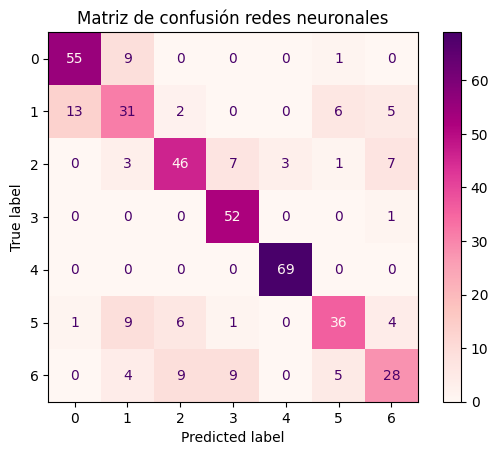

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        65
           1       0.55      0.54      0.55        57
           2       0.73      0.69      0.71        67
           3       0.75      0.98      0.85        53
           4       0.96      1.00      0.98        69
           5       0.73      0.63      0.68        57
           6       0.62      0.51      0.56        55

    accuracy                           0.75       423
   macro avg       0.74      0.74      0.74       423
weighted avg       0.74      0.75      0.74       423

Subconjunto: Filtro


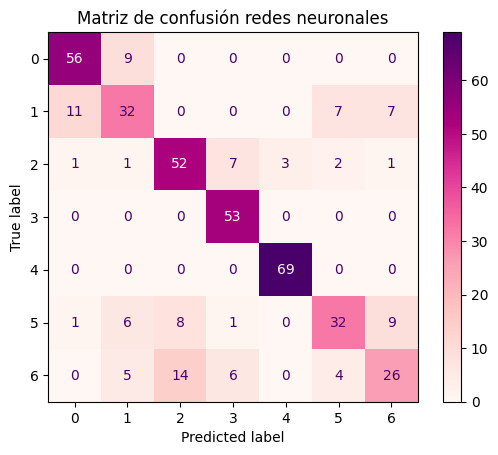

              precision    recall  f1-score   support

           0       0.81      0.86      0.84        65
           1       0.60      0.56      0.58        57
           2       0.70      0.78      0.74        67
           3       0.79      1.00      0.88        53
           4       0.96      1.00      0.98        69
           5       0.71      0.56      0.63        57
           6       0.60      0.47      0.53        55

    accuracy                           0.76       423
   macro avg       0.74      0.75      0.74       423
weighted avg       0.75      0.76      0.75       423

Subconjunto: PCA


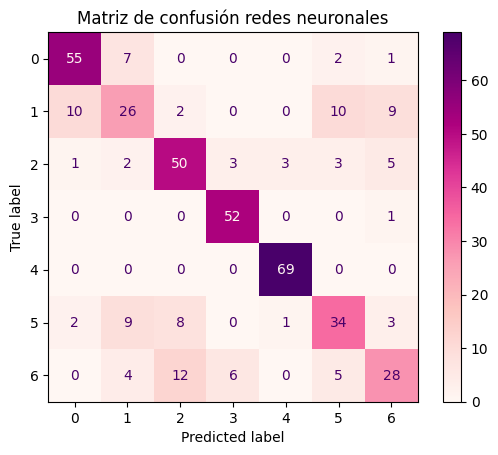

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        65
           1       0.54      0.46      0.50        57
           2       0.69      0.75      0.72        67
           3       0.85      0.98      0.91        53
           4       0.95      1.00      0.97        69
           5       0.63      0.60      0.61        57
           6       0.60      0.51      0.55        55

    accuracy                           0.74       423
   macro avg       0.72      0.73      0.73       423
weighted avg       0.73      0.74      0.73       423

Subconjunto: LDA


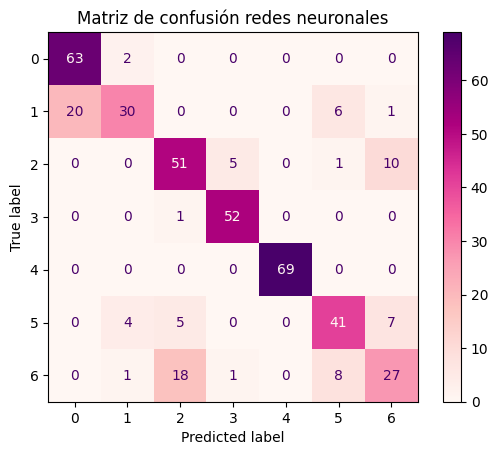

              precision    recall  f1-score   support

           0       0.76      0.97      0.85        65
           1       0.81      0.53      0.64        57
           2       0.68      0.76      0.72        67
           3       0.90      0.98      0.94        53
           4       1.00      1.00      1.00        69
           5       0.73      0.72      0.73        57
           6       0.60      0.49      0.54        55

    accuracy                           0.79       423
   macro avg       0.78      0.78      0.77       423
weighted avg       0.79      0.79      0.78       423



In [141]:
modelos_neuronales = []
for nombre, (X_train, X_test, y_train, y_test) in subconjuntos.items():
    modelo_neuronal = MLPClassifier(early_stopping=True, random_state=0)
    modelo_neuronal.fit(X_train, y_train)
    y_pred_neuronal = modelo_neuronal.predict(X_test)

    print(f"Subconjunto: {nombre}")
    mc_rd = confusion_matrix(y_test, y_pred_neuronal)
    disp = ConfusionMatrixDisplay(confusion_matrix=mc_rd, display_labels=modelo_neuronal.classes_)
    disp.plot(cmap='RdPu')
    plt.title("Matriz de confusión redes neuronales")
    plt.show()
    print(classification_report(y_test, y_pred_neuronal))
    modelos_neuronales.append(modelo_neuronal)

**Buscamos mejores hiperparámetros con gridsearch**

In [143]:
#Modelo con subconjunto completo para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_parametros = {'hidden_layer_sizes': [
                    (80,80,80,80),
                    (100,100,100,100)
                    ],
                   'activation': ['relu', 'tanh'],
                   'alpha': [0.0001, 0.001, 0.01]
                   }


modelo_neuronal_grid_1 = GridSearchCV(estimator=modelos_neuronales[0],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_neuronal_grid_1.fit(X_train1, y_train1)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.883, test=0.849) f1: (train=0.882, test=0.846) precision: (train=0.890, test=0.854) recall: (train=0.882, test=0.845) total time=   1.3s
[CV 2/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.910, test=0.849) f1: (train=0.910, test=0.846) precision: (train=0.914, test=0.858) recall: (train=0.912, test=0.853) total time=   1.5s
[CV 3/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.883, test=0.811) f1: (train=0.882, test=0.810) precision: (train=0.883, test=0.817) recall: (train=0.881, test=0.806) total time=   0.9s
[CV 4/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.927, test=0.819) f1: (train=0.927, test=0.818) precision: (train=0.927, test=0.821) recall: (train=0.927, test=0.820) total time

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(80, ...), (100, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose

In [144]:
#Modelo con subconjunto filtro para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_parametros = {'hidden_layer_sizes': [
                    (80,80,80,80),
                    (100,100,100,100)
                    ],
                   'activation': ['relu', 'tanh'],
                   'alpha': [0.0001, 0.001, 0.01]
                   }


modelo_neuronal_grid_2 = GridSearchCV(estimator=modelos_neuronales[1],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_neuronal_grid_2.fit(X_train2, y_train2)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.893, test=0.817) f1: (train=0.890, test=0.809) precision: (train=0.897, test=0.833) recall: (train=0.891, test=0.813) total time=   2.2s
[CV 2/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.879, test=0.828) f1: (train=0.878, test=0.821) precision: (train=0.880, test=0.821) recall: (train=0.877, test=0.824) total time=   1.5s
[CV 3/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.871, test=0.840) f1: (train=0.869, test=0.837) precision: (train=0.871, test=0.841) recall: (train=0.869, test=0.837) total time=   0.9s
[CV 4/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.823, test=0.757) f1: (train=0.815, test=0.744) precision: (train=0.819, test=0.759) recall: (train=0.821, test=0.755) total time

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(80, ...), (100, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose

In [145]:
#Modelo con subconjunto PCA para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_parametros = {'hidden_layer_sizes': [
                    (80,80,80,80),
                    (100,100,100,100)
                    ],
                   'activation': ['relu', 'tanh'],
                   'alpha': [0.0001, 0.001, 0.01]
                   }


modelo_neuronal_grid_3 = GridSearchCV(estimator=modelos_neuronales[2],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_neuronal_grid_3.fit(X_train3, y_train3)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.936, test=0.858) f1: (train=0.935, test=0.856) precision: (train=0.935, test=0.857) recall: (train=0.935, test=0.858) total time=   1.6s
[CV 2/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.890, test=0.799) f1: (train=0.887, test=0.790) precision: (train=0.889, test=0.790) recall: (train=0.888, test=0.796) total time=   1.1s
[CV 3/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.845, test=0.781) f1: (train=0.843, test=0.779) precision: (train=0.844, test=0.786) recall: (train=0.843, test=0.777) total time=   0.6s
[CV 4/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.853, test=0.736) f1: (train=0.849, test=0.723) precision: (train=0.856, test=0.725) recall: (train=0.849, test=0.731) total time

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(80, ...), (100, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose

In [146]:
#Modelo con subconjunto LDA para la optimización de hiperparámetros
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_parametros = {'hidden_layer_sizes': [
                    (80,80,80,80),
                    (100,100,100,100)
                    ],
                   'activation': ['relu', 'tanh'],
                   'alpha': [0.0001, 0.001, 0.01]
                   }


modelo_neuronal_grid_4 = GridSearchCV(estimator=modelos_neuronales[3],
                              param_grid=grid_parametros,
                              cv=cv,
                              scoring=scoring,
                              refit='accuracy',
                              return_train_score = True,
                              verbose=4)


modelo_neuronal_grid_4.fit(X_train4, y_train4)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.802, test=0.751) f1: (train=0.795, test=0.746) precision: (train=0.795, test=0.749) recall: (train=0.800, test=0.747) total time=   0.7s
[CV 2/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.770, test=0.737) f1: (train=0.763, test=0.727) precision: (train=0.761, test=0.731) recall: (train=0.768, test=0.733) total time=   0.5s
[CV 3/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.813, test=0.793) f1: (train=0.808, test=0.789) precision: (train=0.811, test=0.792) recall: (train=0.811, test=0.792) total time=   0.8s
[CV 4/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(80, 80, 80, 80); accuracy: (train=0.805, test=0.766) f1: (train=0.797, test=0.755) precision: (train=0.802, test=0.763) recall: (train=0.799, test=0.761) total time

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(80, ...), (100, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_macro', 'precision': 'precision_macro', 'recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose

In [147]:
print(modelo_neuronal_grid_1.best_params_, modelo_neuronal_grid_1.best_score_)
print(modelo_neuronal_grid_2.best_params_, modelo_neuronal_grid_2.best_score_)
print(modelo_neuronal_grid_3.best_params_, modelo_neuronal_grid_3.best_score_)
print(modelo_neuronal_grid_4.best_params_, modelo_neuronal_grid_4.best_score_)

{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100, 100, 100)} 0.8329341737924253
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (80, 80, 80, 80)} 0.8032728741242778
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 100, 100, 100)} 0.8033150141344617
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100, 100, 100)} 0.7950011412919424


In [148]:
modelos = [modelo_neuronal_grid_1, modelo_neuronal_grid_2, modelo_neuronal_grid_3, modelo_neuronal_grid_4]
finales = []
for i in modelos:
    resultados = pd.DataFrame(i.cv_results_)

    columnas = [
        'mean_test_accuracy',
        'mean_test_f1',
        'mean_test_precision',
        'mean_test_recall'
]

    display(resultados[columnas].sort_values(
        by='mean_test_accuracy',
        ascending=False
    ).reset_index(drop=True))
    finales.append(resultados)


,mean_test_accuracy,mean_test_f1,mean_test_precision,mean_test_recall
0,0.832934,0.828978,0.834840,0.830252
1,0.832314,0.829569,0.833412,0.830313
2,0.831156,0.826581,0.830151,0.828492
3,0.829363,0.826361,0.829363,0.827471
4,0.825811,0.823674,0.830798,0.824271
5,0.820506,0.815808,0.820385,0.817797
6,0.805073,0.797995,0.802117,0.803358
7,0.799749,0.792804,0.798326,0.797791
8,0.797963,0.790295,0.797350,0.796519
9,0.797963,0.790295,0.797350,0.796519


,mean_test_accuracy,mean_test_f1,mean_test_precision,mean_test_recall
0,0.803273,0.795149,0.803735,0.799931
1,0.789105,0.782120,0.787703,0.784445
2,0.784949,0.776964,0.781916,0.781964
3,0.782582,0.775061,0.777933,0.780266
4,0.777857,0.769391,0.774786,0.774427
5,0.770728,0.759479,0.768740,0.766509
6,0.762408,0.747912,0.756710,0.759411
7,0.762408,0.747912,0.756710,0.759411
8,0.761224,0.746877,0.755487,0.758302
9,0.751774,0.741469,0.747137,0.748147


,mean_test_accuracy,mean_test_f1,mean_test_precision,mean_test_recall
0,0.803315,0.797844,0.800913,0.799937
1,0.796773,0.790868,0.793612,0.793577
2,0.792627,0.785568,0.787492,0.788877
3,0.792622,0.785017,0.787736,0.789035
4,0.790266,0.784600,0.787123,0.788034
5,0.777246,0.769806,0.771774,0.773420
6,0.774858,0.768691,0.771366,0.773064
7,0.767140,0.757476,0.760282,0.763955
8,0.766548,0.756917,0.759605,0.763258
9,0.765393,0.757641,0.760746,0.762873


,mean_test_accuracy,mean_test_f1,mean_test_precision,mean_test_recall
0,0.795001,0.787791,0.792750,0.793512
1,0.789690,0.783639,0.794212,0.786212
2,0.780798,0.774190,0.784658,0.777615
3,0.773710,0.768986,0.773956,0.770931
4,0.772491,0.763974,0.768117,0.770994
5,0.771900,0.763368,0.767383,0.770386
6,0.771900,0.763368,0.767383,0.770386
7,0.767786,0.760994,0.765170,0.764817
8,0.767772,0.759214,0.766717,0.765687
9,0.767772,0.759214,0.766717,0.765687


In [149]:
subconjuntos_items = list(subconjuntos.items())

for (nombre, (X_train, X_test, y_train, y_test)), modelo_grid in zip(subconjuntos_items, modelos):
    
    modelo_final = modelo_grid.best_estimator_
    mejor_idx = modelo_grid.cv_results_['mean_test_accuracy'].argmax()
    
    y_pred_train = modelo_final.predict(X_train)
    y_pred_test = modelo_final.predict(X_test)
    
    resultados = pd.DataFrame([{
        'subconjunto': nombre,
        'acc_train': accuracy_score(y_train, y_pred_train),
        'f1_train': f1_score(y_train, y_pred_train, average='macro'),
        'recall_train': recall_score(y_train, y_pred_train, average='macro'),
        'precision_train': precision_score(y_train, y_pred_train, average='macro'),
        'acc_val': modelo_grid.cv_results_['mean_test_accuracy'][mejor_idx],
        'f1_val': modelo_grid.cv_results_['mean_test_f1'][mejor_idx],
        'recall_val': modelo_grid.cv_results_['mean_test_recall'][mejor_idx],
        'precision_val': modelo_grid.cv_results_['mean_test_precision'][mejor_idx],
        'acc_test': accuracy_score(y_test, y_pred_test),
        'f1_test': f1_score(y_test, y_pred_test, average='macro'),
        'recall_test': recall_score(y_test, y_pred_test, average='macro'),
        'precision_test': precision_score(y_test, y_pred_test, average='macro'),
    }])
    display(resultados)

,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,Completo,0.916469,0.915998,0.916817,0.916381,0.832934,0.828978,0.830252,0.83484,0.846336,0.839719,0.841069,0.839692


,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,Filtro,0.897512,0.89502,0.895512,0.896032,0.803273,0.795149,0.799931,0.803735,0.822695,0.81396,0.816551,0.814099


,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,PCA,0.89218,0.888467,0.890037,0.889982,0.803315,0.797844,0.799937,0.800913,0.765957,0.753916,0.758802,0.752267


,subconjunto,acc_train,f1_train,recall_train,precision_train,acc_val,f1_val,recall_val,precision_val,acc_test,f1_test,recall_test,precision_test
0,LDA,0.832346,0.823507,0.828433,0.83052,0.795001,0.787791,0.793512,0.79275,0.813239,0.799974,0.802467,0.812389


In [150]:
nombres = ['Completo', 'Filtro', 'PCA', 'LDA']

for nombre, resultado in zip(nombres, finales):
    mejor_fila = resultado.sort_values('mean_test_accuracy', ascending=False).iloc[0]

    tabla_resultados = pd.concat([tabla_resultados,
                           pd.DataFrame([{'Modelo': 'Redes Neuronales',
                                          'subconjunto': nombre,
                                          'Accuracy': mejor_fila['mean_test_accuracy'],
                                          'Recall': mejor_fila['mean_test_recall'],
                                          'F1': mejor_fila['mean_test_f1'],
                                          'Precision': mejor_fila['mean_test_precision']}])]
                          , ignore_index=True)

In [151]:
tabla_resultados.drop_duplicates(inplace=True)
tabla_resultados

,Modelo,subconjunto,Accuracy,Recall,F1,Precision
0,Regresión Logística,Completo,0.822695,0.81775,0.816708,0.8181
1,Regresión Logística,Filtro,0.801418,0.794165,0.792537,0.793689
2,Regresión Logística,PCA,0.690307,0.678409,0.665986,0.675475
3,Regresión Logística,LDA,0.763593,0.755436,0.754437,0.756791
4,KNN,Completo,0.825059,0.82032,0.819088,0.819422
5,KNN,Filtro,0.825059,0.820601,0.819168,0.820282
6,KNN,PCA,0.780142,0.774899,0.767968,0.767221
7,KNN,LDA,0.858156,0.853439,0.852324,0.854788
8,Random forest,Completo,0.9236,0.9221,0.9219,0.9296
9,Random forest,Filtro,0.9076,0.9064,0.9056,0.9157


In [154]:
tabla_resultados[['Accuracy', 'Recall', 'F1', 'Precision']] = tabla_resultados[['Accuracy', 'Recall', 'F1', 'Precision']].astype(float)
tabla_resultados['score_promedio'] = tabla_resultados[['Accuracy', 'Recall', 'F1', 'Precision']].mean(axis=1)
top5 = tabla_resultados.nlargest(5, 'score_promedio').drop(columns='score_promedio').reset_index(drop=True)
top5


,Modelo,subconjunto,Accuracy,Recall,F1,Precision
0,Random forest,Completo,0.923600,0.922100,0.921900,0.929600
1,Random forest,Filtro,0.907600,0.906400,0.905600,0.915700
2,Gradient Boosting,Completo,0.910165,0.906576,0.907131,0.910358
3,Gradient Boosting,Filtro,0.891253,0.886626,0.886797,0.889274
4,KNN,LDA,0.858156,0.853439,0.852324,0.854788


Matriz de confusión de los mejores modelos